# PINN-MPC v7 Alpha-Throttle: 2-Input D5 Settle-Trim Start v38

Clean restart of the v7 alpha-throttle MPC notebook with robust checkpoint discovery.

State: `[h, V, theta, q, alpha]`

MPC action: `[elevator, throttle]`

PINN input contract: `[h, V, theta, q, alpha, elevator, throttle, prev_elevator, prev_throttle, delevator, dthrottle]`.


## 0. Install & Imports


In [68]:
!pip install jsbsim optuna -q
print('Install complete')


Install complete


In [69]:
import os, json, time, random, warnings, glob
warnings.filterwarnings('ignore')

import jsbsim
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import optuna

CKPT_FILENAME = 'pinn_dynamics_c172_2d_v7_alpha_throttle.pt'
COMPATIBLE_CKPT_FILENAMES = [
    'pinn_dynamics_c172_2d_v7_alpha_throttle.pt',
]
EXPERIMENT_FAMILY = 'PINN_MPC'
EXPERIMENT_NAME = 'v7_alpha_throttle_snc_D5_2input_MPPI_PID_v38_settle_trim_start'
RUN_STAMP = time.strftime('%Y%m%d_%H%M%S')
COLAB_DRIVE_MOUNTED = False

try:
    from google.colab import drive
    drive.mount('/content/drive')
    COLAB_DRIVE_MOUNTED = True
except Exception:
    COLAB_DRIVE_MOUNTED = False

# Current v7 training notebook saves the alpha-throttle checkpoint here.
# If needed, override MODEL_PATH after this cell before running the checkpoint load cell.
MODEL_PATH_CANDIDATES = []
for _name in COMPATIBLE_CKPT_FILENAMES:
    MODEL_PATH_CANDIDATES += [
        # Standard Google Drive location when Drive is mounted as /content/drive/MyDrive.
        f'/content/drive/MyDrive/PINN_MODEL_ONLY_v2_throttle/{_name}',
        # Common accidental location if a folder was created directly under /content/drive.
        f'/content/drive/PINN_MODEL_ONLY_v2_throttle/{_name}',
        # Timestamped/result folders and older project layouts.
        f'/content/drive/MyDrive/Colab Result/PINN_MPC/{_name}',
        f'/content/drive/MyDrive/Colab Result/PINN_MPC/**/{_name}',
        f'/content/drive/MyDrive/Colab Notebooks/PINN_MPC_Project/current best/PINN_Model/{_name}',
        f'/content/drive/MyDrive/PINN_MPC_Project/current best/PINN_Model/{_name}',
        f'/content/drive/MyDrive/PINN_MPC_Project/PINN_Model/{_name}',
        f'/content/{_name}',
        f'./PINN_MODEL_ONLY_v2_throttle/{_name}',
        f'./PINN_MPC_Project/current best/PINN_Model/{_name}',
        f'./{_name}',
    ]

CHECKPOINT_SEARCH_ROOTS = [
    '/content/drive',
    '/content/drive/MyDrive',
    '/content',
    '.',
]


def find_checkpoint_candidates():
    found = []
    for candidate in MODEL_PATH_CANDIDATES:
        if not candidate:
            continue
        if any(ch in candidate for ch in ['*', '?', '[']):
            try:
                found.extend(glob.glob(candidate, recursive=True))
            except Exception as exc:
                print('Checkpoint glob skipped candidate:', candidate, '|', repr(exc))
        elif os.path.exists(candidate):
            found.append(candidate)

    patterns = []
    for root in CHECKPOINT_SEARCH_ROOTS:
        if os.path.exists(root):
            patterns.append(os.path.join(root, '**', 'pinn_dynamics_c172_2d_v7_alpha_throttle.pt'))
            patterns.append(os.path.join(root, '**', '*v7_alpha_throttle*.pt'))

    for pattern in patterns:
        try:
            found.extend(glob.glob(pattern, recursive=True))
        except Exception as exc:
            print('Checkpoint search skipped pattern:', pattern, '|', repr(exc))

    # De-duplicate while preserving order, then prefer exact v7 alpha-throttle names.
    unique = []
    seen = set()
    for item in found:
        item = os.path.abspath(item)
        if item not in seen and os.path.exists(item):
            unique.append(item)
            seen.add(item)

    def rank(path):
        name = os.path.basename(path)
        if name == 'pinn_dynamics_c172_2d_v7_alpha_throttle.pt':
            return (0, -os.path.getmtime(path))
        return (9, -os.path.getmtime(path))

    return sorted(unique, key=rank)


def resolve_model_path():
    candidates = find_checkpoint_candidates()
    if candidates:
        return candidates[0]
    return MODEL_PATH_CANDIDATES[0]


MODEL_PATH = resolve_model_path()
FOUND_MODEL_PATHS = find_checkpoint_candidates()

# Result policy: code stays in the repository; generated outputs go to a
# separate Colab Result folder. Each run gets a timestamped archive directory.
RESULT_ROOT = '/content/drive/MyDrive/Colab Result' if COLAB_DRIVE_MOUNTED else './Colab Result'
RESULT_MODEL_DIR = os.path.join(RESULT_ROOT, EXPERIMENT_FAMILY, EXPERIMENT_NAME)
RESULT_ARCHIVE_DIR = os.path.join(RESULT_MODEL_DIR, 'archive')
RESULT_LATEST_DIR = os.path.join(RESULT_MODEL_DIR, 'latest')
SAVE_DIR = os.path.join(RESULT_ARCHIVE_DIR, RUN_STAMP)
for _path in [RESULT_ROOT, RESULT_MODEL_DIR, RESULT_ARCHIVE_DIR, RESULT_LATEST_DIR, SAVE_DIR]:
    os.makedirs(_path, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('COLAB_DRIVE_MOUNTED:', COLAB_DRIVE_MOUNTED)
print('MODEL_PATH:', MODEL_PATH)
print('MODEL_EXISTS:', os.path.exists(MODEL_PATH))
print('FOUND_MODEL_PATHS:')
for item in FOUND_MODEL_PATHS[:20]:
    print(' -', item)
if len(FOUND_MODEL_PATHS) > 20:
    print(f' ... {len(FOUND_MODEL_PATHS) - 20} more')
print('RESULT_ROOT:', RESULT_ROOT)
print('RESULT_MODEL_DIR:', RESULT_MODEL_DIR)
print('SAVE_DIR:', SAVE_DIR)
print('RESULT_LATEST_DIR:', RESULT_LATEST_DIR)
if not os.path.exists(MODEL_PATH):
    print('No compatible v7 alpha-throttle checkpoint was found. Put the file in one of these locations:')
    for name in COMPATIBLE_CKPT_FILENAMES:
        print(' - /content/drive/MyDrive/PINN_MODEL_ONLY_v2_throttle/' + name)
        print(' - /content/drive/PINN_MODEL_ONLY_v2_throttle/' + name)
    print('Or set MODEL_PATH manually before running the checkpoint load cell.')

SEED = 123
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cpu
COLAB_DRIVE_MOUNTED: True
MODEL_PATH: /content/drive/MyDrive/PINN_MODEL_ONLY_v2_throttle/pinn_dynamics_c172_2d_v7_alpha_throttle.pt
MODEL_EXISTS: True
FOUND_MODEL_PATHS:
 - /content/drive/MyDrive/PINN_MODEL_ONLY_v2_throttle/pinn_dynamics_c172_2d_v7_alpha_throttle.pt
RESULT_ROOT: /content/drive/MyDrive/Colab Result
RESULT_MODEL_DIR: /content/drive/MyDrive/Colab Result/PINN_MPC/v7_alpha_throttle_snc_D5_2input_MPPI_PID_v38_settle_trim_start
SAVE_DIR: /content/drive/MyDrive/Colab Result/PINN_MPC/v7_alpha_throttle_snc_D5_2input_MPPI_PID_v38_settle_trim_start/archive/20260503_121835
RESULT_LATEST_DIR: /content/drive/MyDrive/Colab Result/PINN_MPC/v7_alpha_throttle_snc_D5_2input_MPPI_PID_v38_settle_trim_start/latest


## 1. Configuration


In [70]:
# Run modes:
# - "quick": cost sanity check + fast PID vs MPPI comparison
# - "debug": MPPI-only short debug run
# - "single": PID vs MPPI with a little more time
# - "full": longer PID, Random Shooting, CEM, MPPI comparison
RUN_MODE = 'disturbance_sweep_2input_fast'
DEBUG_STRICT_ASSERTS = False
NOTEBOOK_REVISION = 'v38_settle_trim_start_v7_alpha_throttle_2input_mppi'

# PINN is loaded only. No PINN data collection or training is performed here.
PINN_LOAD_ONLY = True

# Tune PID directly on JSBSim rollouts across the same fixed maneuver and
# representative disturbance cases. MPPI still uses the nominal PINN internally.
TUNE_PID_WITH_OPTUNA = True
DEFAULT_PID_PARAMS = {
    'kp_alt': 0.0,
    'kp': 2.4,
    'ki': 0.006,
    'kd': 0.45,
    'kq': 0.9,
}

INIT_ALT = 3000.0
TARGET_ALT = INIT_ALT
INIT_THROTTLE = 0.85
THROTTLE = INIT_THROTTLE

USE_JSBSIM_TRIM = False  # JSBSim do_trim can fail for this C172 condition with 'udot not trimmable'.
JSBSIM_TRIM_MODE = 0
USE_SETTLE_TRIM = True
TRIM_SETTLE_SECONDS = 6.0
TRIM_SETTLE_TARGET_PITCH_DEG = 0.0
TRIM_SETTLE_ELEVATOR_LIMIT = 0.22
TRIM_SETTLE_THROTTLE_LIMIT = 0.10
USE_TRIM_PITCH_REFERENCE = True
TRIM_REFERENCE_READY = False
TRIM_PITCH_REFERENCE_DEG = 0.0
TRIM_ELEVATOR_CMD = 0.0
TRIM_THROTTLE_CMD = INIT_THROTTLE
TRIM_STATUS = 'not_run'
DT = 0.02
FPS_PER_KT = 1.6878098571
INIT_SPEED_KTS = 100.0
INIT_SPEED_FPS = INIT_SPEED_KTS * FPS_PER_KT

STATE_COLS = ['h', 'V', 'theta', 'q', 'alpha']
INPUT_COLS = ['elevator', 'throttle', 'prev_elevator', 'prev_throttle', 'delevator', 'dthrottle']
FEAT_COLS = STATE_COLS + INPUT_COLS
TGT_COLS = ['dh', 'dV', 'dtheta', 'dq', 'dalpha']

REACHED_BAND_FT = 100.0
REACHED_HOLD_STEPS = 60

PITCH_LIMIT_DEG = 25.0
PITCH_ABORT_DEG = 65.0
ALPHA_LIMIT_DEG = 18.0
ALT_MIN_FT = 500.0
ALT_MAX_FT = 12000.0

ELEV_LIMIT = 0.45
DELTA_ELEV_LIMIT = 0.08
THROTTLE_MIN = 0.45
THROTTLE_MAX = 1.00
DELTA_THROTTLE_LIMIT = 0.035
THROTTLE_TRACK_SCALE = 0.18

# Recompute MPC only every N JSBSim steps. Quick mode uses 0.20 s updates.
CONTROL_INTERVAL = 10

# Explicit controller-test guidance. This is not PINN training guidance.
GUIDANCE_KIND = 'smooth_pitch_doublet'
SIM_TIME_S = 30.0
GUIDANCE_CLIMB_RATE_FPS = 0.0
GUIDANCE_CLIMB_TIME_S = SIM_TIME_S
GUIDANCE_LINEAR_START_ALT_FT = INIT_ALT
GUIDANCE_LINEAR_TARGET_ALT_FT = TARGET_ALT
GUIDANCE_TRIM_ALPHA_RAD = 0.035
GUIDANCE_AIRSPEED_KTS = 95.0
GUIDANCE_AIRSPEED_FPS = GUIDANCE_AIRSPEED_KTS * FPS_PER_KT
SPEED_FLOOR_KTS = 75.0
SPEED_FLOOR_FPS = SPEED_FLOOR_KTS * FPS_PER_KT
SPEED_TRACK_SCALE_FPS = 12.0
TERMINAL_SPEED_SCALE_FPS = 9.0
SUSTAINED_AUTHORITY_SECONDS = SIM_TIME_S
SUSTAINED_MIN_SPEED_KTS = SPEED_FLOOR_KTS
SUSTAINED_MIN_SPEED_FPS = SPEED_FLOOR_FPS
MANEUVER_KIND = GUIDANCE_KIND
MANEUVER_START_S = 5.0
MANEUVER_HALF_PERIOD_S = 3.0
MANEUVER_TOTAL_TIME_S = 2.0 * MANEUVER_HALF_PERIOD_S
MANEUVER_RECOVERY_S = 12.0
PITCH_DOUBLET_AMPLITUDE_DEG = 5.0
PITCH_PULSE_AMPLITUDE_DEG = 6.0
PITCH_PUSHOVER_AMPLITUDE_DEG = -4.0
DISTURBANCE_KIND = 'none'
DISTURBANCE_START_S = 7.0
DISTURBANCE_END_S = 11.0
DISTURBANCE_ELEVATOR_BIAS = 0.0
DISTURBANCE_ELEVATOR_SINE_AMP = 0.0
DISTURBANCE_ELEVATOR_FREQ_HZ = 0.35
DISTURBANCE_CASES = [
    {'name': 'W0_nominal', 'family': 'none', 'severity': 0.0, 'kind': 'none', 'bias': 0.0, 'sine_amp': 0.0, 'freq_hz': 0.35, 'start_s': 7.0, 'end_s': 11.0},
    {'name': 'W1_step_up_weak', 'family': 'step', 'severity': 1.0, 'kind': 'elevator_step', 'bias': 0.012, 'sine_amp': 0.0, 'freq_hz': 0.35, 'start_s': 7.0, 'end_s': 11.0},
    {'name': 'W2_step_down_weak', 'family': 'step', 'severity': 1.0, 'kind': 'elevator_step', 'bias': -0.012, 'sine_amp': 0.0, 'freq_hz': 0.35, 'start_s': 7.0, 'end_s': 11.0},
    {'name': 'W3_sine_slow', 'family': 'sine', 'severity': 1.0, 'kind': 'elevator_sine', 'bias': 0.0, 'sine_amp': 0.018, 'freq_hz': 0.20, 'start_s': 7.0, 'end_s': 11.0},
    {'name': 'W4_sine_fast', 'family': 'sine', 'severity': 1.0, 'kind': 'elevator_sine', 'bias': 0.0, 'sine_amp': 0.018, 'freq_hz': 0.75, 'start_s': 7.0, 'end_s': 11.0},
    {'name': 'W5_mixed_up_medium', 'family': 'mixed', 'severity': 2.0, 'kind': 'elevator_sine_step', 'bias': 0.018, 'sine_amp': 0.016, 'freq_hz': 0.35, 'start_s': 7.0, 'end_s': 11.0},
    {'name': 'W6_mixed_down_medium', 'family': 'mixed', 'severity': 2.0, 'kind': 'elevator_sine_step', 'bias': -0.018, 'sine_amp': -0.016, 'freq_hz': 0.35, 'start_s': 7.0, 'end_s': 11.0},
    {'name': 'W7_mixed_up_strong', 'family': 'mixed', 'severity': 3.0, 'kind': 'elevator_sine_step', 'bias': 0.026, 'sine_amp': 0.022, 'freq_hz': 0.35, 'start_s': 7.0, 'end_s': 11.0},
    {'name': 'W8_mixed_down_strong', 'family': 'mixed', 'severity': 3.0, 'kind': 'elevator_sine_step', 'bias': -0.026, 'sine_amp': -0.022, 'freq_hz': 0.35, 'start_s': 7.0, 'end_s': 11.0},
]
MANEUVER_CASES = [
    {'name': 'D3_smooth_doublet', 'kind': 'smooth_pitch_doublet', 'doublet_amp_deg': 3.0, 'pulse_amp_deg': 5.0, 'pushover_amp_deg': -3.0},
    {'name': 'D5_smooth_doublet', 'kind': 'smooth_pitch_doublet', 'doublet_amp_deg': 5.0, 'pulse_amp_deg': 6.0, 'pushover_amp_deg': -4.0},
    {'name': 'D7_smooth_doublet', 'kind': 'smooth_pitch_doublet', 'doublet_amp_deg': 7.0, 'pulse_amp_deg': 7.0, 'pushover_amp_deg': -5.0},
    {'name': 'PU5_pullup', 'kind': 'pullup', 'doublet_amp_deg': 5.0, 'pulse_amp_deg': 5.0, 'pushover_amp_deg': -4.0},
    {'name': 'PO4_pushover', 'kind': 'pushover', 'doublet_amp_deg': 5.0, 'pulse_amp_deg': 5.0, 'pushover_amp_deg': -4.0},
    {'name': 'PUPO_6_4', 'kind': 'pullup_pushover', 'doublet_amp_deg': 5.0, 'pulse_amp_deg': 6.0, 'pushover_amp_deg': -4.0},
]
PID_TUNING_CASE_NAMES = ['W0_nominal', 'W1_step_up_weak', 'W2_step_down_weak', 'W5_mixed_up_medium', 'W6_mixed_down_medium']
PID_TUNING_WEIGHTS = [0.40, 0.15, 0.15, 0.15, 0.15]
PID_TUNING_MANEUVER_NAMES = ['D5_smooth_doublet']
PID_TUNING_MANEUVER_WEIGHTS = [1.0]
MPPI_SAMPLE_SWEEP = [32]
MPPI_SWEEP_SEEDS = [0]
ACTIVE_DISTURBANCE_CASE = dict(DISTURBANCE_CASES[0])
if RUN_MODE == 'multi_maneuver_fast':
    FAST_MANEUVER_CASES = ['D3_smooth_doublet', 'D5_smooth_doublet', 'PUPO_6_4']
    FAST_DISTURBANCE_CASES = ['W0_nominal', 'W1_pos_sine_step', 'W2_neg_sine_step']
    MANEUVER_CASES = [case for case in MANEUVER_CASES if case['name'] in FAST_MANEUVER_CASES]
    DISTURBANCE_CASES = [case for case in DISTURBANCE_CASES if case['name'] in FAST_DISTURBANCE_CASES]
    PID_TUNING_MANEUVER_NAMES = ['D5_smooth_doublet']
    PID_TUNING_CASE_NAMES = ['W0_nominal', 'W1_step_up_weak', 'W2_step_down_weak', 'W5_mixed_up_medium', 'W6_mixed_down_medium']
    PID_TUNING_MANEUVER_WEIGHTS = [1.0] * len(PID_TUNING_MANEUVER_NAMES)
    PID_TUNING_WEIGHTS = [0.40, 0.15, 0.15, 0.15, 0.15] * len(PID_TUNING_CASE_NAMES)
CURRENT_GUIDANCE_TIME = 0.0
GUIDANCE_ALT_TRACK_SCALE_FT = 10.0
ALT_HOLD_SCALE_FT = 20.0
ALT_TERMINAL_SCALE_FT = 8.0
ALT_VS_SCALE_FPS = 3.0
GUIDANCE_VS_SCALE_FPS = 6.5
GUIDANCE_Q_SCALE_RAD_S = 0.10
THETA_CMD_LIMIT = 0.18
THETA_TRACK_SCALE = 0.045
# Altitude-hold augmentation: add a small pitch bias when the aircraft loses
# altitude or has downward vertical speed. This makes both PID and MPPI track
# the same altitude-aware pitch reference instead of an open-loop pitch shape.
ALT_HOLD_GUIDANCE_ENABLE = True
ALT_HOLD_THETA_KP_DEG_PER_100FT = 2.8
ALT_HOLD_THETA_KV_DEG_PER_10FPS = 1.8
ALT_ERROR_INTEGRAL_ENABLE = True
ALT_ERROR_INTEGRAL_LIMIT_FT_S = 600.0
ALT_HOLD_THETA_KI_DEG_PER_100FTS = 0.75
ALT_HOLD_THETA_LIMIT_DEG = 7.0
CURRENT_ALT_ERROR_INTEGRAL = 0.0
GLOBAL_ALT_SCALE_FT = 600.0
GUIDANCE_PROGRESS_SCALE_FT = 8.0

# MPPI is still stochastic, so a few deterministic anchor sequences are added
# to avoid missing the climb direction with very small sample counts.
MPPI_USE_ANCHOR_SEQUENCES = True
MPPI_ANCHOR_LEVELS = [-0.30, -0.15, 0.0, 0.15, 0.30]

if RUN_MODE == 'disturbance_sweep_2input_fast':
    MAX_STEPS = 900
    PID_TRIALS = 100
    MPC_HORIZON = 100
    MPC_SAMPLES = 24
    CEM_ITERS = 1
    N_TEST_CASES = len(DISTURBANCE_CASES)
    CONTROL_INTERVAL = 10
    SELECTED_CONTROLLERS = ['PID', 'MPPI']
elif RUN_MODE == 'multi_maneuver_fast':
    MAX_STEPS = 900
    PID_TRIALS = 100
    MPC_HORIZON = 100
    MPC_SAMPLES = 24
    CEM_ITERS = 1
    N_TEST_CASES = 1
    CONTROL_INTERVAL = 10
    SELECTED_CONTROLLERS = ['PID', 'MPPI']
elif RUN_MODE == 'multi_maneuver':
    MAX_STEPS = 900
    PID_TRIALS = 10
    MPC_HORIZON = 100
    MPC_SAMPLES = 32
    CEM_ITERS = 1
    N_TEST_CASES = len(DISTURBANCE_CASES)
    CONTROL_INTERVAL = 10
    SELECTED_CONTROLLERS = ['PID', 'MPPI']
elif RUN_MODE == 'sample_sweep':
    MAX_STEPS = 900
    PID_TRIALS = 0
    MPC_HORIZON = 100
    MPC_SAMPLES = 16
    CEM_ITERS = 1
    N_TEST_CASES = 1
    CONTROL_INTERVAL = 10
    SELECTED_CONTROLLERS = ['MPPI']
elif RUN_MODE == 'quick':
    MAX_STEPS = 900
    PID_TRIALS = 0
    MPC_HORIZON = 100
    MPC_SAMPLES = 16
    CEM_ITERS = 1
    N_TEST_CASES = len(DISTURBANCE_CASES)
    CONTROL_INTERVAL = 10
    SELECTED_CONTROLLERS = ['PID', 'MPPI']
elif RUN_MODE == 'optpid_fast':
    MAX_STEPS = 900
    PID_TRIALS = 14
    MPC_HORIZON = 100
    MPC_SAMPLES = 18
    CEM_ITERS = 1
    N_TEST_CASES = len(DISTURBANCE_CASES)
    CONTROL_INTERVAL = 10
    SELECTED_CONTROLLERS = ['PID', 'MPPI']
elif RUN_MODE == 'debug':
    MAX_STEPS = 500
    PID_TRIALS = 0
    MPC_HORIZON = 100
    MPC_SAMPLES = 16
    CEM_ITERS = 1
    N_TEST_CASES = len(DISTURBANCE_CASES)
    CONTROL_INTERVAL = 10
    SELECTED_CONTROLLERS = ['MPPI']
elif RUN_MODE == 'single':
    MAX_STEPS = int(SIM_TIME_S / DT)
    PID_TRIALS = 18
    MPC_HORIZON = 120
    MPC_SAMPLES = 12
    CEM_ITERS = 1
    N_TEST_CASES = len(DISTURBANCE_CASES)
    CONTROL_INTERVAL = 10
    SELECTED_CONTROLLERS = ['PID', 'MPPI']
elif RUN_MODE == 'full':
    MAX_STEPS = int(SIM_TIME_S / DT)
    PID_TRIALS = 30
    MPC_HORIZON = 160
    MPC_SAMPLES = 20
    CEM_ITERS = 1
    N_TEST_CASES = 2
    SELECTED_CONTROLLERS = ['PID', 'Random', 'CEM', 'MPPI']
    TUNE_PID_WITH_OPTUNA = True
else:
    raise ValueError(f'Unknown RUN_MODE: {RUN_MODE}')

MPC_HORIZON_SECONDS = MPC_HORIZON * DT
CONTROL_INTERVAL_SECONDS = CONTROL_INTERVAL * DT
GUIDANCE_LINEAR_RATE_FPS = 0.0

CONFIG = dict(
    RUN_MODE=RUN_MODE,
    DEBUG_STRICT_ASSERTS=DEBUG_STRICT_ASSERTS,
    NOTEBOOK_REVISION=NOTEBOOK_REVISION,
    EXPERIMENT_FAMILY=EXPERIMENT_FAMILY,
    EXPERIMENT_NAME=EXPERIMENT_NAME,
    RUN_STAMP=RUN_STAMP,
    RESULT_ROOT=RESULT_ROOT,
    RESULT_MODEL_DIR=RESULT_MODEL_DIR,
    RESULT_ARCHIVE_DIR=RESULT_ARCHIVE_DIR,
    RESULT_LATEST_DIR=RESULT_LATEST_DIR,
    SAVE_DIR=SAVE_DIR,
    PINN_LOAD_ONLY=PINN_LOAD_ONLY,
    TUNE_PID_WITH_OPTUNA=TUNE_PID_WITH_OPTUNA,
    PID_TRIALS=PID_TRIALS,
    INIT_ALT=INIT_ALT,
    TARGET_ALT=TARGET_ALT,
    THROTTLE=THROTTLE,
    FPS_PER_KT=FPS_PER_KT,
    INIT_SPEED_KTS=INIT_SPEED_KTS,
    INIT_SPEED_FPS=INIT_SPEED_FPS,
    DT=DT,
    MAX_STEPS=MAX_STEPS,
    MPC_HORIZON=MPC_HORIZON,
    MPC_HORIZON_SECONDS=MPC_HORIZON_SECONDS,
    MPC_SAMPLES=MPC_SAMPLES,
    CEM_ITERS=CEM_ITERS,
    N_TEST_CASES=N_TEST_CASES,
    CONTROL_INTERVAL=CONTROL_INTERVAL,
    CONTROL_INTERVAL_SECONDS=CONTROL_INTERVAL_SECONDS,
    SELECTED_CONTROLLERS=SELECTED_CONTROLLERS,
    ELEV_LIMIT=ELEV_LIMIT,
    DELTA_ELEV_LIMIT=DELTA_ELEV_LIMIT,
    THROTTLE_MIN=THROTTLE_MIN,
    THROTTLE_MAX=THROTTLE_MAX,
    DELTA_THROTTLE_LIMIT=DELTA_THROTTLE_LIMIT,
    THROTTLE_TRACK_SCALE=THROTTLE_TRACK_SCALE,
    GUIDANCE_KIND=GUIDANCE_KIND,
    GUIDANCE_CLIMB_TIME_S=GUIDANCE_CLIMB_TIME_S,
    GUIDANCE_LINEAR_START_ALT_FT=GUIDANCE_LINEAR_START_ALT_FT,
    GUIDANCE_LINEAR_TARGET_ALT_FT=GUIDANCE_LINEAR_TARGET_ALT_FT,
    MANEUVER_KIND=MANEUVER_KIND,
    MANEUVER_TOTAL_TIME_S=MANEUVER_TOTAL_TIME_S,
    MANEUVER_START_S=MANEUVER_START_S,
    MANEUVER_HALF_PERIOD_S=MANEUVER_HALF_PERIOD_S,
    MANEUVER_RECOVERY_S=MANEUVER_RECOVERY_S,
    PITCH_DOUBLET_AMPLITUDE_DEG=PITCH_DOUBLET_AMPLITUDE_DEG,
    PITCH_PULSE_AMPLITUDE_DEG=PITCH_PULSE_AMPLITUDE_DEG,
    PITCH_PUSHOVER_AMPLITUDE_DEG=PITCH_PUSHOVER_AMPLITUDE_DEG,
    DISTURBANCE_CASES=DISTURBANCE_CASES,
    MANEUVER_CASES=MANEUVER_CASES,
    PID_TUNING_CASE_NAMES=PID_TUNING_CASE_NAMES,
    PID_TUNING_WEIGHTS=PID_TUNING_WEIGHTS,
    PID_TUNING_MANEUVER_NAMES=PID_TUNING_MANEUVER_NAMES,
    PID_TUNING_MANEUVER_WEIGHTS=PID_TUNING_MANEUVER_WEIGHTS,
    MPPI_SAMPLE_SWEEP=MPPI_SAMPLE_SWEEP,
    MPPI_SWEEP_SEEDS=MPPI_SWEEP_SEEDS,
    ACTIVE_DISTURBANCE_CASE=ACTIVE_DISTURBANCE_CASE,
    GUIDANCE_CLIMB_RATE_FPS=GUIDANCE_CLIMB_RATE_FPS,
    GUIDANCE_LINEAR_RATE_FPS=GUIDANCE_LINEAR_RATE_FPS,
    SIM_TIME_S=SIM_TIME_S,
    PID_ELEVATOR_SIGN=-1.0,
    EXPECTED_ALT_AT_SIM_END=GUIDANCE_LINEAR_TARGET_ALT_FT,
    SCENARIO_NOTE="Fixed D5 smooth pitch doublet; 2-input elevator+throttle PINN-MPPI vs PID+speed-throttle baseline under disturbance sweep.",
    SPEED_UNIT_NOTE='JSBSim ic/vt-kts uses knots; PINN state V uses ft/s.',
    GUIDANCE_TRIM_ALPHA_RAD=GUIDANCE_TRIM_ALPHA_RAD,
    GUIDANCE_AIRSPEED_KTS=GUIDANCE_AIRSPEED_KTS,
    SPEED_FLOOR_KTS=SPEED_FLOOR_KTS,
    SPEED_FLOOR_FPS=SPEED_FLOOR_FPS,
    SPEED_TRACK_SCALE_FPS=SPEED_TRACK_SCALE_FPS,
    TERMINAL_SPEED_SCALE_FPS=TERMINAL_SPEED_SCALE_FPS,
    SUSTAINED_AUTHORITY_SECONDS=SUSTAINED_AUTHORITY_SECONDS,
    SUSTAINED_MIN_SPEED_KTS=SUSTAINED_MIN_SPEED_KTS,
    SUSTAINED_MIN_SPEED_FPS=SUSTAINED_MIN_SPEED_FPS,
    GUIDANCE_AIRSPEED_FPS=GUIDANCE_AIRSPEED_FPS,
    GUIDANCE_ALT_TRACK_SCALE_FT=GUIDANCE_ALT_TRACK_SCALE_FT,
    ALT_HOLD_SCALE_FT=ALT_HOLD_SCALE_FT,
    ALT_TERMINAL_SCALE_FT=ALT_TERMINAL_SCALE_FT,
    ALT_VS_SCALE_FPS=ALT_VS_SCALE_FPS,
    GUIDANCE_VS_SCALE_FPS=GUIDANCE_VS_SCALE_FPS,
    GUIDANCE_Q_SCALE_RAD_S=GUIDANCE_Q_SCALE_RAD_S,
    THETA_CMD_LIMIT=THETA_CMD_LIMIT,
    THETA_TRACK_SCALE=THETA_TRACK_SCALE,
    ALT_HOLD_GUIDANCE_ENABLE=ALT_HOLD_GUIDANCE_ENABLE,
    ALT_HOLD_THETA_KP_DEG_PER_100FT=ALT_HOLD_THETA_KP_DEG_PER_100FT,
    ALT_HOLD_THETA_KV_DEG_PER_10FPS=ALT_HOLD_THETA_KV_DEG_PER_10FPS,
    ALT_ERROR_INTEGRAL_ENABLE=ALT_ERROR_INTEGRAL_ENABLE,
    ALT_ERROR_INTEGRAL_LIMIT_FT_S=ALT_ERROR_INTEGRAL_LIMIT_FT_S,
    ALT_HOLD_THETA_KI_DEG_PER_100FTS=ALT_HOLD_THETA_KI_DEG_PER_100FTS,
    ALT_HOLD_THETA_LIMIT_DEG=ALT_HOLD_THETA_LIMIT_DEG,
    GLOBAL_ALT_SCALE_FT=GLOBAL_ALT_SCALE_FT,
    GUIDANCE_PROGRESS_SCALE_FT=GUIDANCE_PROGRESS_SCALE_FT,
    MPPI_USE_ANCHOR_SEQUENCES=MPPI_USE_ANCHOR_SEQUENCES,
    MPPI_ANCHOR_LEVELS=MPPI_ANCHOR_LEVELS,
)
print(json.dumps(CONFIG, indent=2))


{
  "RUN_MODE": "disturbance_sweep_2input_fast",
  "DEBUG_STRICT_ASSERTS": false,
  "NOTEBOOK_REVISION": "v38_settle_trim_start_v7_alpha_throttle_2input_mppi",
  "EXPERIMENT_FAMILY": "PINN_MPC",
  "EXPERIMENT_NAME": "v7_alpha_throttle_snc_D5_2input_MPPI_PID_v38_settle_trim_start",
  "RUN_STAMP": "20260503_121835",
  "RESULT_ROOT": "/content/drive/MyDrive/Colab Result",
  "RESULT_MODEL_DIR": "/content/drive/MyDrive/Colab Result/PINN_MPC/v7_alpha_throttle_snc_D5_2input_MPPI_PID_v38_settle_trim_start",
  "RESULT_ARCHIVE_DIR": "/content/drive/MyDrive/Colab Result/PINN_MPC/v7_alpha_throttle_snc_D5_2input_MPPI_PID_v38_settle_trim_start/archive",
  "RESULT_LATEST_DIR": "/content/drive/MyDrive/Colab Result/PINN_MPC/v7_alpha_throttle_snc_D5_2input_MPPI_PID_v38_settle_trim_start/latest",
  "SAVE_DIR": "/content/drive/MyDrive/Colab Result/PINN_MPC/v7_alpha_throttle_snc_D5_2input_MPPI_PID_v38_settle_trim_start/archive/20260503_121835",
  "PINN_LOAD_ONLY": true,
  "TUNE_PID_WITH_OPTUNA": true,
  "P

## 2. JSBSim Plant Helpers


In [71]:
def get_prop(fdm, name, default=0.0):
    try:
        return float(fdm[name])
    except Exception:
        return float(default)


def update_trim_reference_from_fdm(fdm, status='unknown', elevator_cmd=None, throttle_cmd=None):
    global TRIM_REFERENCE_READY, TRIM_PITCH_REFERENCE_DEG, TRIM_ELEVATOR_CMD, TRIM_THROTTLE_CMD, TRIM_STATUS
    theta_deg = float(np.degrees(get_prop(fdm, 'attitude/theta-rad', 0.0)))
    elev_cmd = get_prop(fdm, 'fcs/elevator-cmd-norm', 0.0) if elevator_cmd is None else elevator_cmd
    thr_cmd = get_prop(fdm, 'fcs/throttle-cmd-norm', INIT_THROTTLE) if throttle_cmd is None else throttle_cmd
    TRIM_PITCH_REFERENCE_DEG = theta_deg if USE_TRIM_PITCH_REFERENCE else 0.0
    TRIM_ELEVATOR_CMD = float(np.clip(elev_cmd, -1.0, 1.0))
    TRIM_THROTTLE_CMD = float(np.clip(thr_cmd, 0.0, 1.0))
    TRIM_STATUS = str(status)
    TRIM_REFERENCE_READY = True


def settle_fdm_to_trim_reference(fdm, seconds=TRIM_SETTLE_SECONDS):
    steps = max(1, int(float(seconds) / DT))
    elev_cmd = TRIM_ELEVATOR_CMD
    throttle_cmd = TRIM_THROTTLE_CMD
    target_speed_fps = INIT_SPEED_FPS
    for _ in range(steps):
        theta_deg = float(np.degrees(get_prop(fdm, 'attitude/theta-rad', 0.0)))
        q_deg_s = float(np.degrees(get_prop(fdm, 'velocities/q-rad_sec', 0.0)))
        speed_fps = float(get_prop(fdm, 'velocities/vt-fps', INIT_SPEED_FPS))
        # Positive elevator gives nose-down response in this setup; use a small
        # damping controller only to remove the initial non-trim transient.
        pitch_err = theta_deg - TRIM_SETTLE_TARGET_PITCH_DEG
        elev_cmd = float(np.clip(0.030 * pitch_err + 0.018 * q_deg_s,
                                 -TRIM_SETTLE_ELEVATOR_LIMIT, TRIM_SETTLE_ELEVATOR_LIMIT))
        throttle_delta = 0.0040 * ((target_speed_fps - speed_fps) / FPS_PER_KT)
        throttle_cmd = float(np.clip(INIT_THROTTLE + throttle_delta,
                                     INIT_THROTTLE - TRIM_SETTLE_THROTTLE_LIMIT,
                                     INIT_THROTTLE + TRIM_SETTLE_THROTTLE_LIMIT))
        fdm['propulsion/engine/set-running'] = 1
        fdm['fcs/elevator-cmd-norm'] = elev_cmd
        fdm['fcs/throttle-cmd-norm'] = throttle_cmd
        fdm.run()
    update_trim_reference_from_fdm(fdm, f'settle:{seconds:.1f}s', elev_cmd, throttle_cmd)
    return elev_cmd, throttle_cmd


def make_fdm(init_alt=INIT_ALT, init_speed=INIT_SPEED_KTS, init_pitch=0.0, use_trim=USE_JSBSIM_TRIM):
    fdm = jsbsim.FGFDMExec(None, None)
    fdm.set_debug_level(0)
    fdm.load_model('c172p')
    fdm['ic/h-sl-ft'] = float(init_alt)
    # JSBSim initial condition expects knots. read_state() returns ft/s.
    fdm['ic/vt-kts'] = float(init_speed)
    fdm['ic/theta-deg'] = float(init_pitch)
    fdm['ic/psi-true-deg'] = 0.0
    fdm.run_ic()
    fdm['propulsion/engine/set-running'] = 1
    fdm['fcs/throttle-cmd-norm'] = INIT_THROTTLE
    fdm['fcs/elevator-cmd-norm'] = 0.0
    trim_status = 'ic_only'
    if use_trim:
        try:
            result = fdm.do_trim(JSBSIM_TRIM_MODE)
            trim_status = f'jsbsim_trim_ok:{result}'
        except Exception as exc:
            trim_status = f'jsbsim_trim_failed:{type(exc).__name__}:{exc}'
    if USE_SETTLE_TRIM:
        settle_fdm_to_trim_reference(fdm, TRIM_SETTLE_SECONDS)
    else:
        update_trim_reference_from_fdm(fdm, trim_status)
    fdm['propulsion/engine/set-running'] = 1
    return fdm


def ensure_trim_reference():
    fdm = make_fdm(init_alt=INIT_ALT, init_speed=INIT_SPEED_KTS, init_pitch=0.0, use_trim=USE_JSBSIM_TRIM)
    state = read_state(fdm)
    print(
        f'Trim reference: status={TRIM_STATUS}, pitch_ref={TRIM_PITCH_REFERENCE_DEG:.3f} deg, '
        f'elevator={TRIM_ELEVATOR_CMD:.4f}, throttle={TRIM_THROTTLE_CMD:.4f}, '
        f'h={state[0]:.1f} ft, V={state[1] / FPS_PER_KT:.2f} kt'
    )
    return state

def read_state(fdm):
    return np.array([
        get_prop(fdm, 'position/h-sl-ft'),
        get_prop(fdm, 'velocities/vt-fps'),
        get_prop(fdm, 'attitude/theta-rad'),
        get_prop(fdm, 'velocities/q-rad_sec'),
        get_prop(fdm, 'aero/alpha-rad', 0.0),
    ], dtype=np.float32)


def set_disturbance_case(case):
    global ACTIVE_DISTURBANCE_CASE
    ACTIVE_DISTURBANCE_CASE = dict(case)


def set_maneuver_case(case):
    global MANEUVER_KIND, PITCH_DOUBLET_AMPLITUDE_DEG, PITCH_PULSE_AMPLITUDE_DEG, PITCH_PUSHOVER_AMPLITUDE_DEG
    MANEUVER_KIND = case.get('kind', MANEUVER_KIND)
    PITCH_DOUBLET_AMPLITUDE_DEG = float(case.get('doublet_amp_deg', PITCH_DOUBLET_AMPLITUDE_DEG))
    PITCH_PULSE_AMPLITUDE_DEG = float(case.get('pulse_amp_deg', PITCH_PULSE_AMPLITUDE_DEG))
    PITCH_PUSHOVER_AMPLITUDE_DEG = float(case.get('pushover_amp_deg', PITCH_PUSHOVER_AMPLITUDE_DEG))


def elevator_disturbance(t):
    case = ACTIVE_DISTURBANCE_CASE
    kind = case.get('kind', 'none')
    if kind in (None, 'none'):
        return 0.0
    start_s = float(case.get('start_s', DISTURBANCE_START_S))
    end_s = float(case.get('end_s', DISTURBANCE_END_S))
    if t < start_s or t > end_s:
        return 0.0
    tau = t - start_s
    bias = float(case.get('bias', 0.0))
    sine_amp = float(case.get('sine_amp', 0.0))
    freq_hz = float(case.get('freq_hz', DISTURBANCE_ELEVATOR_FREQ_HZ))
    if kind == 'elevator_step':
        return bias
    if kind == 'elevator_sine':
        return sine_amp * np.sin(2.0 * np.pi * freq_hz * tau)
    if kind == 'elevator_sine_step':
        return bias + sine_amp * np.sin(2.0 * np.pi * freq_hz * tau)
    raise ValueError(f'Unknown disturbance kind: {kind}')


def apply_control(fdm, elevator, throttle=None, t=0.0, disturbance=0.0):
    if throttle is None:
        throttle = TRIM_THROTTLE_CMD
    total_elevator = float(np.clip(elevator + disturbance, -1.0, 1.0))
    total_throttle = float(np.clip(throttle, 0.0, 1.0))
    fdm['propulsion/engine/set-running'] = 1
    fdm['fcs/throttle-cmd-norm'] = total_throttle
    fdm['fcs/elevator-cmd-norm'] = total_elevator
    fdm.run()
    return total_elevator, total_throttle



## 3. Load Saved v7 Alpha-Throttle PINN Checkpoint

This section reconstructs the network architecture and loads `model_state` from disk. It does not train, fit, optimize, or update the PINN parameters.


In [72]:
class PhysicsPINN(nn.Module):
    def __init__(self, hidden_dim=192, n_layers=4, stats=None):
        super().__init__()
        input_dim = len(FEAT_COLS)
        output_dim = len(TGT_COLS)
        self.register_buffer('Xm', stats['Xm'].clone() if stats else torch.zeros(input_dim))
        self.register_buffer('Xs', stats['Xs'].clone() if stats else torch.ones(input_dim))
        self.register_buffer('Ym', stats['Ym'].clone() if stats else torch.zeros(output_dim))
        self.register_buffer('Ys', stats['Ys'].clone() if stats else torch.ones(output_dim))

        layers = [nn.Linear(input_dim, hidden_dim), nn.SiLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.SiLU()]
        layers.append(nn.Linear(hidden_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x_norm):
        return self.net(x_norm)

    def denorm_delta(self, d_norm, add_mean=True):
        if add_mean:
            return d_norm * self.Ys + self.Ym
        return d_norm * self.Ys


def _torch_load_checkpoint(path):
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)


def load_pinn_checkpoint(path):
    candidates = []
    if path and os.path.exists(path):
        candidates.append(path)
    candidates.extend([p for p in FOUND_MODEL_PATHS if p not in candidates])

    load_errors = []
    for candidate in candidates:
        try:
            ckpt = _torch_load_checkpoint(candidate)
            missing = [k for k in ['model_state', 'stats', 'best_params'] if k not in ckpt]
            if missing:
                load_errors.append(f'{candidate}: missing keys {missing}')
                continue
            ckpt_features = list(ckpt.get('feature_cols', FEAT_COLS))
            ckpt_targets = list(ckpt.get('target_cols', TGT_COLS))
            if ckpt_features != FEAT_COLS or ckpt_targets != TGT_COLS:
                load_errors.append(
                    f'{candidate}: contract mismatch features={ckpt_features}, targets={ckpt_targets}'
                )
                continue
            return ckpt, candidate
        except Exception as exc:
            load_errors.append(f'{candidate}: {type(exc).__name__}: {exc}')

    message = [
        'Missing compatible trained PINN checkpoint.',
        f'Initial MODEL_PATH: {path}',
        'Expected feature contract:', str(FEAT_COLS),
        'Expected target contract:', str(TGT_COLS),
        'Searched/found candidates:',
    ]
    message += [f' - {p}' for p in (FOUND_MODEL_PATHS or MODEL_PATH_CANDIDATES[:20])]
    if load_errors:
        message += ['Load attempts:'] + [f' - {err}' for err in load_errors]
    message += [
        'Fix: run the v7 alpha-throttle training notebook first, then copy/save the checkpoint to:',
        '/content/drive/MyDrive/PINN_MODEL_ONLY_v2_throttle/pinn_dynamics_c172_2d_v7_alpha_throttle.pt',
        'Also accepted: /content/drive/PINN_MODEL_ONLY_v2_throttle/pinn_dynamics_c172_2d_v7_alpha_throttle.pt',
        'If your training run saved into a timestamped Colab Result folder, set MODEL_PATH manually to that .pt file before this cell.',
    ]
    raise FileNotFoundError('\n'.join(message))


assert PINN_LOAD_ONLY is True
checkpoint, MODEL_PATH = load_pinn_checkpoint(MODEL_PATH)

stats = {k: v.to(device) for k, v in checkpoint['stats'].items()}
params = checkpoint['best_params']

model = PhysicsPINN(
    hidden_dim=params.get('hidden_dim', 192),
    n_layers=params.get('n_layers', 4),
    stats=stats,
).to(device)
model.load_state_dict(checkpoint['model_state'])
model.eval()
for p in model.parameters():
    p.requires_grad_(False)

ckpt_feature_cols = checkpoint.get('feature_cols', FEAT_COLS)
ckpt_target_cols = checkpoint.get('target_cols', TGT_COLS)

print('Loaded compatible PINN checkpoint:', MODEL_PATH)
print('PINN parameters frozen:', not any(p.requires_grad for p in model.parameters()))
print('best_params:', params)
print('feature_cols:', ckpt_feature_cols)
print('target_cols:', ckpt_target_cols)
print('auto_summary:', json.dumps(checkpoint.get('auto_summary', {}), indent=2))


Loaded compatible PINN checkpoint: /content/drive/MyDrive/PINN_MODEL_ONLY_v2_throttle/pinn_dynamics_c172_2d_v7_alpha_throttle.pt
PINN parameters frozen: True
best_params: {'hidden_dim': 224, 'n_layers': 4, 'lr': 0.0005, 'lam_physics': 0.1, 'lam_smooth': 0.0005, 'lam_rollout': 0.12, 'target_weights': [1.0, 1.4, 2.0, 8.0, 2.0], 'epochs': 420}
feature_cols: ['h', 'V', 'theta', 'q', 'alpha', 'elevator', 'throttle', 'prev_elevator', 'prev_throttle', 'delevator', 'dthrottle']
target_cols: ['dh', 'dV', 'dtheta', 'dq', 'dalpha']
auto_summary: {
  "best_cycle": 0,
  "best_rollout_score_val": 0.2617944882147842,
  "best_h_rmse_mean_val": 0.3242169409990311,
  "best_theta_rmse_mean_val": 0.0005410125391790644,
  "best_q_rmse_mean_val": 0.0010804211691720412,
  "final_rollout_score_test": 0.20196115210872245,
  "final_h_rmse_mean_test": 0.24550377652049066,
  "final_theta_rmse_mean_test": 0.0005130001845827792,
  "final_q_rmse_mean_test": 0.0007997382170287892,
  "test_targets_met": true,
  "auto_

## 4. PINN Rollout for Control


In [73]:
@torch.no_grad()
def pinn_step(model, state, elevator, throttle, prev_elevator, prev_throttle):
    elevator = float(np.clip(elevator, -ELEV_LIMIT, ELEV_LIMIT))
    throttle = float(np.clip(throttle, THROTTLE_MIN, THROTTLE_MAX))
    prev_elevator = float(np.clip(prev_elevator, -ELEV_LIMIT, ELEV_LIMIT))
    prev_throttle = float(np.clip(prev_throttle, THROTTLE_MIN, THROTTLE_MAX))
    delevator = elevator - prev_elevator
    dthrottle = throttle - prev_throttle
    x = np.array([state[0], state[1], state[2], state[3], state[4],
                  elevator, throttle, prev_elevator, prev_throttle, delevator, dthrottle], dtype=np.float32)
    xt = torch.tensor(x, dtype=torch.float32, device=device).unsqueeze(0)
    xn = (xt - model.Xm) / model.Xs
    dn = model(xn)
    delta = model.denorm_delta(dn, add_mean=True).cpu().numpy()[0]
    return state + delta


def _as_action_sequence(action_seq, horizon=None):
    arr = np.asarray(action_seq, dtype=np.float32)
    if arr.ndim == 1:
        arr = np.stack([arr, np.ones_like(arr) * TRIM_THROTTLE_CMD], axis=1)
    if arr.shape[1] != 2:
        raise ValueError('action sequence must have shape [H, 2] for [elevator, throttle]')
    if horizon is not None:
        arr = arr[:int(horizon)]
    return arr.astype(np.float32)


@torch.no_grad()
def rollout_pinn_control(model, init_state, action_seq, prev_action=None):
    actions = _as_action_sequence(action_seq)
    states = [np.asarray(init_state, dtype=np.float32).copy()]
    current = states[0].copy()
    if prev_action is None:
        prev_elev, prev_thr = TRIM_ELEVATOR_CMD, TRIM_THROTTLE_CMD
    else:
        prev_elev, prev_thr = [float(v) for v in np.asarray(prev_action).ravel()[:2]]
    applied = []
    for raw_elev, raw_thr in actions:
        elev = float(np.clip(raw_elev, prev_elev - DELTA_ELEV_LIMIT, prev_elev + DELTA_ELEV_LIMIT))
        elev = float(np.clip(elev, -ELEV_LIMIT, ELEV_LIMIT))
        thr = float(np.clip(raw_thr, prev_thr - DELTA_THROTTLE_LIMIT, prev_thr + DELTA_THROTTLE_LIMIT))
        thr = float(np.clip(thr, THROTTLE_MIN, THROTTLE_MAX))
        current = pinn_step(model, current, elev, thr, prev_elev, prev_thr)
        states.append(current.copy())
        applied.append([elev, thr])
        prev_elev, prev_thr = elev, thr
    return np.asarray(states), np.asarray(applied, dtype=np.float32)


print('2-input PINN control rollout ready')


2-input PINN control rollout ready


## 5. PID Baseline Tuning


In [74]:
class TunedPID:
    def __init__(self, params):
        self.kp_alt = params.get('kp_alt', 0.0)
        self.kp = params['kp']
        self.ki = params['ki']
        self.kd = params['kd']
        self.kq = params.get('kq', 0.0)
        self.kv = params.get('kv', 0.006)
        self.kv_i = params.get('kv_i', 0.0002)
        self.integral = 0.0
        self.speed_integral = 0.0
        self.prev_err = 0.0
        self.prev_elev = 0.0
        self.prev_throttle = TRIM_THROTTLE_CMD
        self.ILIM = 8.0
        self.VILIM = 400.0

    def reset(self):
        self.integral = 0.0
        self.speed_integral = 0.0
        self.prev_err = 0.0
        self.prev_elev = 0.0
        self.prev_throttle = TRIM_THROTTLE_CMD

    def update(self, state, target_alt):
        h, V, theta, q, alpha = state
        theta_cmd = guidance_first_theta(state, target_alt)
        err = theta_cmd - theta
        self.integral = np.clip(self.integral + err * DT, -self.ILIM, self.ILIM)
        deriv = (err - self.prev_err) / DT
        self.prev_err = err
        raw_cmd = self.kp * err + self.ki * self.integral + self.kd * deriv - self.kq * q
        raw = -raw_cmd
        elev = np.clip(raw, self.prev_elev - DELTA_ELEV_LIMIT, self.prev_elev + DELTA_ELEV_LIMIT)
        elev = np.clip(elev, -ELEV_LIMIT, ELEV_LIMIT)
        self.prev_elev = float(elev)

        speed_err = GUIDANCE_AIRSPEED_FPS - V
        self.speed_integral = np.clip(self.speed_integral + speed_err * DT, -self.VILIM, self.VILIM)
        raw_thr = TRIM_THROTTLE_CMD + self.kv * speed_err + self.kv_i * self.speed_integral
        throttle = np.clip(raw_thr, self.prev_throttle - DELTA_THROTTLE_LIMIT, self.prev_throttle + DELTA_THROTTLE_LIMIT)
        throttle = np.clip(throttle, THROTTLE_MIN, THROTTLE_MAX)
        self.prev_throttle = float(throttle)
        return np.array([float(elev), float(throttle)], dtype=np.float32), {
            'theta_cmd': float(theta_cmd), 'cost': abs(theta_cmd - theta), 'throttle_cmd': float(throttle)
        }


def eval_pid_params(params, case=None, init_alt=INIT_ALT, target_alt=TARGET_ALT, n_steps=None):
    case = DISTURBANCE_CASES[0] if case is None else case
    set_disturbance_case(case)
    controller = TunedPID(params)
    fdm = make_fdm(init_alt=init_alt, init_speed=INIT_SPEED_KTS)
    n_steps = int(SIM_TIME_S / DT) if n_steps is None else int(n_steps)
    pitch, theta_ref, q_vals, alpha_vals, elevs, throttles, alt, speed = [], [], [], [], [], [], [], []
    global CURRENT_GUIDANCE_TIME
    for step in range(n_steps):
        t_now = step * DT
        CURRENT_GUIDANCE_TIME = t_now
        state = read_state(fdm)
        h, V, theta, q, alpha = state
        if h < ALT_MIN_FT or h > ALT_MAX_FT or abs(np.degrees(theta)) > PITCH_ABORT_DEG:
            return 1e8
        action, info = controller.update(state, target_alt)
        disturb = elevator_disturbance(t_now)
        applied_elev, applied_thr = apply_control(fdm, action[0], action[1], t=t_now, disturbance=disturb)
        pitch.append(np.degrees(theta)); theta_ref.append(np.degrees(info['theta_cmd']))
        q_vals.append(np.degrees(q)); alpha_vals.append(np.degrees(alpha))
        elevs.append(applied_elev); throttles.append(applied_thr); alt.append(h); speed.append(V)

    pitch = np.asarray(pitch); theta_ref = np.asarray(theta_ref)
    q_vals = np.asarray(q_vals); alpha_vals = np.asarray(alpha_vals)
    elevs = np.asarray(elevs); throttles = np.asarray(throttles)
    alt = np.asarray(alt); speed = np.asarray(speed)
    err = pitch - theta_ref
    pitch_rmse = np.sqrt(np.nanmean(err ** 2))
    peak_err = np.nanmax(np.abs(err))
    final_err = abs(err[-1])
    pitch_pen = 2.0 * np.mean(np.maximum(0.0, np.abs(pitch) - PITCH_LIMIT_DEG) ** 2)
    alpha_pen = 2.0 * np.mean(np.maximum(0.0, np.abs(alpha_vals) - ALPHA_LIMIT_DEG) ** 2)
    q_pen = 0.015 * np.mean(q_vals ** 2)
    effort = 2.0 * np.mean(np.diff(elevs, prepend=elevs[0]) ** 2) + 0.4 * np.mean(np.diff(throttles, prepend=throttles[0]) ** 2)
    alt_rmse = np.sqrt(np.mean((alt - target_alt) ** 2))
    final_alt_err = abs(alt[-1] - target_alt)
    speed_floor_pen = np.mean(np.maximum(0.0, SPEED_FLOOR_FPS - speed) / SPEED_TRACK_SCALE_FPS)
    speed_ref_pen = np.sqrt(np.mean(((speed - GUIDANCE_AIRSPEED_FPS) / SPEED_TRACK_SCALE_FPS) ** 2))
    return float(1.10 * pitch_rmse + 0.20 * peak_err + 0.10 * final_err + 0.050 * alt_rmse
                 + 0.040 * final_alt_err + 0.22 * speed_floor_pen + 0.08 * speed_ref_pen
                 + pitch_pen + alpha_pen + q_pen + effort)


def pid_objective(trial):
    params = {
        'kp_alt': 0.0,
        'kp': trial.suggest_float('kp', 0.15, 5.0, log=True),
        'ki': trial.suggest_float('ki', 0.0001, 0.08, log=True),
        'kd': trial.suggest_float('kd', 0.01, 2.5, log=True),
        'kq': trial.suggest_float('kq', 0.0, 2.5),
        'kv': trial.suggest_float('kv', 0.001, 0.018, log=True),
        'kv_i': trial.suggest_float('kv_i', 0.00001, 0.0015, log=True),
    }
    case_map = {case['name']: case for case in DISTURBANCE_CASES}
    maneuver_map = {case['name']: case for case in MANEUVER_CASES}
    total = 0.0
    for mw, mname in zip(PID_TUNING_MANEUVER_WEIGHTS, PID_TUNING_MANEUVER_NAMES):
        set_maneuver_case(maneuver_map[mname])
        for dw, dname in zip(PID_TUNING_WEIGHTS, PID_TUNING_CASE_NAMES):
            total += mw * dw * eval_pid_params(params, case_map[dname])
    return float(total)


def tune_pid_if_requested():
    global PID_PARAMS
    if TUNE_PID_WITH_OPTUNA and PID_TRIALS > 0:
        print(f'Tuning 2-input PID gains with {PID_TRIALS} Optuna trials on maneuvers {PID_TUNING_MANEUVER_NAMES} and disturbances {PID_TUNING_CASE_NAMES}.')
        pid_study = optuna.create_study(direction='minimize')
        pid_study.optimize(pid_objective, n_trials=PID_TRIALS, show_progress_bar=True)
        PID_PARAMS = dict(pid_study.best_params)
        PID_PARAMS['kp_alt'] = 0.0
        print('Best PID params:', PID_PARAMS)
        print('Best PID objective:', pid_study.best_value)
        return pid_study
    PID_PARAMS = dict(DEFAULT_PID_PARAMS)
    PID_PARAMS.setdefault('kv', 0.006)
    PID_PARAMS.setdefault('kv_i', 0.0002)
    print('Using DEFAULT_PID_PARAMS without Optuna:', PID_PARAMS)
    return None


PID_PARAMS = dict(DEFAULT_PID_PARAMS)
print('2-input PID class and Optuna tuner ready')


2-input PID class and Optuna tuner ready


## 6. MPC Cost Function


In [75]:
def _as_state_vector(current_state):
    arr = np.asarray(current_state, dtype=np.float32)
    if arr.ndim == 0 or arr.size == 1:
        return np.array([INIT_ALT, GUIDANCE_AIRSPEED_FPS, 0.0, 0.0, GUIDANCE_TRIM_ALPHA_RAD], dtype=np.float32)
    if arr.size < 5:
        raise ValueError('Guidance requires state [h, V, theta, q, alpha] or a scalar fallback.')
    return arr[:5].astype(np.float32)


def pitch_maneuver_theta_profile(t_abs):
    t_abs = np.asarray(t_abs, dtype=np.float32)
    theta_deg = np.zeros_like(t_abs, dtype=np.float32)
    a = float(PITCH_DOUBLET_AMPLITUDE_DEG)
    t0 = float(MANEUVER_START_S)
    half = float(MANEUVER_HALF_PERIOD_S)
    tau = t_abs - t0

    if MANEUVER_KIND in ('smooth_pitch_doublet', 'pitch_doublet'):
        first = (tau >= 0.0) & (tau < half)
        second = (tau >= half) & (tau < 2.0 * half)
        # Smooth S&C-style doublet: each lobe starts and ends at zero with a
        # half-sine shape, avoiding an impossible pitch step command.
        theta_deg[first] = a * np.sin(np.pi * tau[first] / half)
        theta_deg[second] = -a * np.sin(np.pi * (tau[second] - half) / half)
    elif MANEUVER_KIND == 'pullup_pushover':
        first = (tau >= 0.0) & (tau < half)
        second = (tau >= half) & (tau < 2.0 * half)
        theta_deg[first] = float(PITCH_PULSE_AMPLITUDE_DEG) * np.sin(np.pi * tau[first] / half)
        theta_deg[second] = float(PITCH_PUSHOVER_AMPLITUDE_DEG) * np.sin(np.pi * (tau[second] - half) / half)
    elif MANEUVER_KIND == 'pullup':
        first = (tau >= 0.0) & (tau < half)
        theta_deg[first] = float(PITCH_PULSE_AMPLITUDE_DEG) * np.sin(np.pi * tau[first] / half)
    elif MANEUVER_KIND == 'pushover':
        first = (tau >= 0.0) & (tau < half)
        theta_deg[first] = float(PITCH_PUSHOVER_AMPLITUDE_DEG) * np.sin(np.pi * tau[first] / half)
    else:
        raise ValueError(f'Unknown MANEUVER_KIND: {MANEUVER_KIND}')
    offset_deg = TRIM_PITCH_REFERENCE_DEG if USE_TRIM_PITCH_REFERENCE else 0.0
    return np.deg2rad(theta_deg + offset_deg).astype(np.float32)




def maneuver_reference_arrays(t, target_alt=TARGET_ALT):
    t = np.asarray(t, dtype=float)
    theta_ref_deg = np.degrees(pitch_maneuver_theta_profile(t))
    h_ref = np.ones_like(t) * float(target_alt)
    return h_ref, theta_ref_deg


def altitude_hold_theta_correction(h, h_ref, vz=None, vz_ref=0.0, alt_error_integral=0.0):
    h = np.asarray(h, dtype=np.float32)
    h_ref = np.asarray(h_ref, dtype=np.float32)
    alt_err = h_ref - h
    corr_deg = ALT_HOLD_THETA_KP_DEG_PER_100FT * (alt_err / 100.0)
    if vz is not None:
        vz = np.asarray(vz, dtype=np.float32)
        corr_deg += ALT_HOLD_THETA_KV_DEG_PER_10FPS * ((float(vz_ref) - vz) / 10.0)
    if ALT_ERROR_INTEGRAL_ENABLE:
        integ = np.asarray(alt_error_integral, dtype=np.float32)
        corr_deg += ALT_HOLD_THETA_KI_DEG_PER_100FTS * (integ / 100.0)
    corr_deg = np.clip(corr_deg, -ALT_HOLD_THETA_LIMIT_DEG, ALT_HOLD_THETA_LIMIT_DEG)
    return np.deg2rad(corr_deg).astype(np.float32)


def make_pitch_maneuver_guidance(current_state, target_alt, horizon, dt):
    state = _as_state_vector(current_state)
    h0, V0, theta0, q0, alpha0 = [float(v) for v in state]
    horizon = int(horizon)
    if horizon <= 0:
        raise ValueError('horizon must be positive')

    t_rel = np.arange(horizon, dtype=np.float32) * float(dt)
    t_abs = float(CURRENT_GUIDANCE_TIME) + t_rel
    theta_base_ref = pitch_maneuver_theta_profile(t_abs)
    h_ref = np.ones(horizon, dtype=np.float32) * float(target_alt)
    if ALT_HOLD_GUIDANCE_ENABLE:
        # For the controller command, use the current altitude error as the
        # immediate pitch bias. The MPC cost adds a trajectory-wise correction
        # below using each predicted altitude sequence.
        theta_ref = theta_base_ref + altitude_hold_theta_correction(h0, h_ref, vz=0.0, vz_ref=0.0, alt_error_integral=CURRENT_ALT_ERROR_INTEGRAL)
    else:
        theta_ref = theta_base_ref
    theta_ref = np.clip(theta_ref, -THETA_CMD_LIMIT, THETA_CMD_LIMIT).astype(np.float32)
    q_ref = np.gradient(theta_ref, dt).astype(np.float32)
    vz_ref = np.zeros(horizon, dtype=np.float32)
    speed_ref = np.ones(horizon, dtype=np.float32) * GUIDANCE_AIRSPEED_FPS
    alpha_ref = np.ones(horizon, dtype=np.float32) * np.clip(
        GUIDANCE_TRIM_ALPHA_RAD if abs(alpha0) < 0.20 else alpha0,
        -0.12, 0.16,
    )
    return {
        'h_ref': h_ref,
        'vz_ref': vz_ref,
        'V_ref': speed_ref.astype(np.float32),
        'theta_ref': theta_ref,
        'theta_base_ref': theta_base_ref.astype(np.float32),
        'q_ref': q_ref,
        'alpha_ref': alpha_ref,
        'target_alt': float(target_alt),
        'desired_vs': 0.0,
        'initial_error': float(target_alt - h0),
        'profile': MANEUVER_KIND,
        't_abs': t_abs.astype(np.float32),
    }


def make_linear_altitude_guidance(current_state, target_alt, horizon, dt):
    return make_pitch_maneuver_guidance(current_state, target_alt, horizon, dt)


def make_maneuver_guidance(current_state, target_alt, horizon, dt, maneuver='pitch_doublet'):
    return make_pitch_maneuver_guidance(current_state, target_alt, horizon, dt)


def make_mpc_altitude_guidance(current_state, target_alt, horizon, dt):
    return make_maneuver_guidance(current_state, target_alt, horizon, dt, maneuver=GUIDANCE_KIND)


def make_altitude_guidance(current_state, target_alt, horizon, dt):
    guide = make_mpc_altitude_guidance(current_state, target_alt, horizon, dt)
    return guide['h_ref'], guide['vz_ref'], guide['theta_ref']


def guidance_first_theta(current_state, target_alt):
    guide = make_mpc_altitude_guidance(current_state, target_alt, 2, DT)
    return float(guide['theta_ref'][0])


def mpc_cost_components(predicted, target_alt, action_seq):
    h = predicted[:, 0]; V = predicted[:, 1]; theta = predicted[:, 2]; q = predicted[:, 3]; alpha = predicted[:, 4]
    action_seq = _as_action_sequence(action_seq)
    elev_seq = action_seq[:, 0]; throttle_seq = action_seq[:, 1]
    guide = make_mpc_altitude_guidance(predicted[0], target_alt, len(h), DT)
    h_ref = guide['h_ref']; theta_ref = guide['theta_ref']; q_ref = guide['q_ref']; alpha_ref = guide['alpha_ref']; V_ref = guide['V_ref']
    dhdt = np.diff(h, prepend=h[0]) / DT
    if ALT_HOLD_GUIDANCE_ENABLE:
        theta_base_ref = guide.get('theta_base_ref', theta_ref)
        pred_alt_err = guide['h_ref'] - h
        pred_integral = np.clip(CURRENT_ALT_ERROR_INTEGRAL + np.cumsum(pred_alt_err) * DT, -ALT_ERROR_INTEGRAL_LIMIT_FT_S, ALT_ERROR_INTEGRAL_LIMIT_FT_S)
        theta_ref = theta_base_ref + altitude_hold_theta_correction(h, guide['h_ref'], vz=dhdt, vz_ref=0.0, alt_error_integral=pred_integral)
        theta_ref = np.clip(theta_ref, -THETA_CMD_LIMIT, THETA_CMD_LIMIT).astype(np.float32)
        q_ref = np.gradient(theta_ref, DT).astype(np.float32)
    theta_deg = np.degrees(theta); q_deg = np.degrees(q); alpha_deg = np.degrees(alpha)
    components = {
        'theta_track': 15.00 * np.mean(((theta - theta_ref) / THETA_TRACK_SCALE) ** 2),
        'theta_terminal': 9.00 * ((theta[-1] - theta_ref[-1]) / THETA_TRACK_SCALE) ** 2,
        'q_track': 0.20 * np.mean(((q - q_ref) / GUIDANCE_Q_SCALE_RAD_S) ** 2),
        'alpha_track': 0.05 * np.mean(((alpha - alpha_ref) / max(np.deg2rad(8.0), 1e-6)) ** 2),
        'alt_hold': 5.00 * np.mean(((h - h_ref) / ALT_HOLD_SCALE_FT) ** 2),
        'alt_terminal': 25.00 * ((h[-1] - h_ref[-1]) / ALT_TERMINAL_SCALE_FT) ** 2,
        'alt_low': 12.00 * np.mean((np.maximum(0.0, h_ref - h) / ALT_HOLD_SCALE_FT) ** 2),
        'alt_terminal_low': 45.00 * (max(0.0, float(h_ref[-1] - h[-1])) / ALT_TERMINAL_SCALE_FT) ** 2,
        'sink_rate': 10.00 * np.mean((np.maximum(0.0, -dhdt) / ALT_VS_SCALE_FPS) ** 2),
        'vz_hold': 2.20 * np.mean((dhdt / ALT_VS_SCALE_FPS) ** 2),
        'speed_track': 1.80 * np.mean(((V - V_ref) / SPEED_TRACK_SCALE_FPS) ** 2),
        'terminal_speed': 1.40 * ((V[-1] - V_ref[-1]) / TERMINAL_SPEED_SCALE_FPS) ** 2,
        'speed_floor': 4.00 * np.mean((np.maximum(0.0, SPEED_FLOOR_FPS - V) / SPEED_TRACK_SCALE_FPS) ** 2),
        'pitch_limit': 25.0 * np.mean(np.maximum(0.0, np.abs(theta_deg) - PITCH_LIMIT_DEG) ** 2),
        'alpha_limit': 25.0 * np.mean(np.maximum(0.0, np.abs(alpha_deg) - ALPHA_LIMIT_DEG) ** 2),
        'q_penalty': 0.004 * np.mean(q_deg ** 2),
        'elevator_effort': 0.003 * np.mean(elev_seq ** 2) if len(elev_seq) else 0.0,
        'elevator_smooth': 0.020 * np.mean(np.diff(elev_seq, prepend=elev_seq[0]) ** 2) if len(elev_seq) else 0.0,
        'throttle_effort': 0.060 * np.mean(((throttle_seq - INIT_THROTTLE) / THROTTLE_TRACK_SCALE) ** 2) if len(throttle_seq) else 0.0,
        'throttle_smooth': 0.080 * np.mean((np.diff(throttle_seq, prepend=throttle_seq[0]) / max(DELTA_THROTTLE_LIMIT, 1e-6)) ** 2) if len(throttle_seq) else 0.0,
    }
    unsafe = np.any((h < ALT_MIN_FT) | (h > ALT_MAX_FT) | (np.abs(theta_deg) > PITCH_ABORT_DEG))
    components['abort'] = 1e3 if unsafe else 0.0
    components = {k: float(v) for k, v in components.items()}
    components['total'] = float(sum(components.values()))
    return components, guide


def mpc_cost(predicted, target_alt, action_seq):
    components, _ = mpc_cost_components(predicted, target_alt, action_seq)
    return components['total']


## 7. PINN-MPC Controllers


In [76]:
class MPPIMPC:
    """2-input MPPI over [elevator, throttle]."""
    def __init__(self, horizon=MPC_HORIZON, n_samples=MPC_SAMPLES, sigma=None, lam=0.12):
        self.horizon = horizon
        self.n_samples = n_samples
        self.sigma = np.asarray(sigma if sigma is not None else [0.22, 0.055], dtype=np.float32)
        self.lam = lam
        self.U = np.zeros((horizon, 2), dtype=np.float32)
        self.U[:, 1] = TRIM_THROTTLE_CMD
        self.prev_action = np.array([TRIM_ELEVATOR_CMD, TRIM_THROTTLE_CMD], dtype=np.float32)

    def reset(self):
        self.U[:] = 0.0
        self.U[:, 1] = TRIM_THROTTLE_CMD
        self.prev_action = np.array([TRIM_ELEVATOR_CMD, TRIM_THROTTLE_CMD], dtype=np.float32)

    def anchor_sequences(self):
        anchors = []
        if MPPI_USE_ANCHOR_SEQUENCES:
            for elev_level in MPPI_ANCHOR_LEVELS:
                for thr_level in [TRIM_THROTTLE_CMD, min(THROTTLE_MAX, INIT_THROTTLE + 0.08), max(THROTTLE_MIN, INIT_THROTTLE - 0.08)]:
                    seq = np.zeros((self.horizon, 2), dtype=np.float32)
                    seq[:, 0] = float(elev_level); seq[:, 1] = float(thr_level)
                    anchors.append(seq)
            for sign in [1.0, -1.0]:
                seq = np.zeros((self.horizon, 2), dtype=np.float32)
                seq[:, 0] = np.linspace(0.0, sign * 0.30, self.horizon, dtype=np.float32)
                seq[:, 1] = np.linspace(TRIM_THROTTLE_CMD, min(THROTTLE_MAX, INIT_THROTTLE + 0.10), self.horizon, dtype=np.float32)
                anchors.append(seq)
        return anchors

    def update(self, state, target_alt):
        eps = np.random.normal(0.0, self.sigma[None, None, :], size=(self.n_samples, self.horizon, 2)).astype(np.float32)
        seqs = self.U[None, :, :] + eps
        seqs[:, :, 0] = np.clip(seqs[:, :, 0], -ELEV_LIMIT, ELEV_LIMIT)
        seqs[:, :, 1] = np.clip(seqs[:, :, 1], THROTTLE_MIN, THROTTLE_MAX)
        anchors = self.anchor_sequences()
        if anchors:
            seqs = np.concatenate([seqs, np.asarray(anchors, dtype=np.float32)], axis=0)
        costs = np.empty(len(seqs), dtype=np.float32)
        applied_cache = []
        for i, seq in enumerate(seqs):
            pred, applied = rollout_pinn_control(model, state, seq, self.prev_action)
            costs[i] = mpc_cost(pred, target_alt, applied)
            applied_cache.append(applied)
        beta = costs.min()
        weights = np.exp(-(costs - beta) / max(self.lam, 1e-6))
        weights = weights / (weights.sum() + 1e-9)
        applied_arr = np.asarray(applied_cache, dtype=np.float32)
        weighted_seq = np.sum(weights[:, None, None] * applied_arr, axis=0)
        self.U = weighted_seq.astype(np.float32)
        self.U[:, 0] = np.clip(self.U[:, 0], -ELEV_LIMIT, ELEV_LIMIT)
        self.U[:, 1] = np.clip(self.U[:, 1], THROTTLE_MIN, THROTTLE_MAX)
        action = self.U[0].copy()
        action[0] = np.clip(action[0], self.prev_action[0] - DELTA_ELEV_LIMIT, self.prev_action[0] + DELTA_ELEV_LIMIT)
        action[1] = np.clip(action[1], self.prev_action[1] - DELTA_THROTTLE_LIMIT, self.prev_action[1] + DELTA_THROTTLE_LIMIT)
        action[0] = np.clip(action[0], -ELEV_LIMIT, ELEV_LIMIT)
        action[1] = np.clip(action[1], THROTTLE_MIN, THROTTLE_MAX)
        self.prev_action = action.astype(np.float32)
        self.U = np.vstack([self.U[1:], self.U[-1:]]).astype(np.float32)
        best_idx = int(np.argmin(costs))
        best_applied = applied_cache[best_idx]
        return action.astype(np.float32), {
            'cost': float(np.sum(weights * costs)),
            'best_cost': float(beta),
            'best_first_elevator': float(best_applied[0, 0]),
            'best_first_throttle': float(best_applied[0, 1]),
            'weighted_first_elevator': float(action[0]),
            'weighted_first_throttle': float(action[1]),
        }


print('2-input MPPI controller ready')
print(f'  Horizon          : {MPC_HORIZON} steps = {MPC_HORIZON_SECONDS:.2f} seconds')
print('  Action           : [elevator, throttle]')
print(f'  Samples          : {MPC_SAMPLES}')


2-input MPPI controller ready
  Horizon          : 100 steps = 2.00 seconds
  Action           : [elevator, throttle]
  Samples          : 24


## 8. Simulation Runner


In [77]:
def run_sim(controller, name, init_alt=INIT_ALT, init_speed=INIT_SPEED_KTS, init_pitch=0.0,
            target_alt=TARGET_ALT, max_steps=None, control_interval=CONTROL_INTERVAL):
    global CURRENT_GUIDANCE_TIME, CURRENT_ALT_ERROR_INTEGRAL
    fdm = make_fdm(init_alt=init_alt, init_speed=init_speed, init_pitch=init_pitch)
    controller.reset()
    CURRENT_ALT_ERROR_INTEGRAL = 0.0
    hold_count = 0
    abort_reason = None
    max_steps = MAX_STEPS if max_steps is None else int(max_steps)
    last_action = np.array([TRIM_ELEVATOR_CMD, TRIM_THROTTLE_CMD], dtype=np.float32)
    last_info = {'theta_cmd': np.nan, 'cost': np.nan, 'throttle_cmd': TRIM_THROTTLE_CMD}
    last_comp_ms = 0.0
    log = {k: [] for k in [
        'time', 'altitude', 'velocity', 'pitch_deg', 'pitch_rate_deg_s',
        'alpha_deg', 'elevator', 'elevator_cmd', 'elevator_disturbance',
        'throttle', 'throttle_cmd', 'theta_cmd_deg', 'cost', 'comp_ms', 'mpc_update'
    ]}
    for step in range(max_steps):
        state = read_state(fdm)
        h, V, theta, q, alpha = state
        if h < ALT_MIN_FT:
            abort_reason = f'LOW_ALT {h:.1f} ft'; break
        if h > ALT_MAX_FT:
            abort_reason = f'HIGH_ALT {h:.1f} ft'; break
        if abs(np.degrees(theta)) > PITCH_ABORT_DEG:
            abort_reason = f'PITCH_ABORT {np.degrees(theta):.1f} deg'; break
        t_now = step * DT
        CURRENT_GUIDANCE_TIME = t_now
        if ALT_ERROR_INTEGRAL_ENABLE:
            CURRENT_ALT_ERROR_INTEGRAL = float(np.clip(
                CURRENT_ALT_ERROR_INTEGRAL + (target_alt - h) * DT,
                -ALT_ERROR_INTEGRAL_LIMIT_FT_S, ALT_ERROR_INTEGRAL_LIMIT_FT_S))
        do_update = (step % control_interval == 0)
        if do_update:
            t0 = time.perf_counter()
            last_action, last_info = controller.update(state, target_alt)
            last_action = np.asarray(last_action, dtype=np.float32)
            last_comp_ms = (time.perf_counter() - t0) * 1000.0
        disturb = elevator_disturbance(t_now)
        applied_elev, applied_thr = apply_control(fdm, last_action[0], last_action[1], t=t_now, disturbance=disturb)
        log['time'].append(t_now); log['altitude'].append(float(h)); log['velocity'].append(float(V))
        log['pitch_deg'].append(float(np.degrees(theta))); log['pitch_rate_deg_s'].append(float(np.degrees(q)))
        log['alpha_deg'].append(float(np.degrees(alpha)))
        log['elevator'].append(float(applied_elev)); log['elevator_cmd'].append(float(last_action[0]))
        log['elevator_disturbance'].append(float(disturb))
        log['throttle'].append(float(applied_thr)); log['throttle_cmd'].append(float(last_action[1]))
        log['theta_cmd_deg'].append(float(np.degrees(last_info.get('theta_cmd', np.nan))))
        log['cost'].append(float(last_info.get('cost', np.nan)))
        log['comp_ms'].append(float(last_comp_ms if do_update else 0.0)); log['mpc_update'].append(bool(do_update))
        if GUIDANCE_KIND == 'linear_altitude':
            if abs(h - target_alt) < REACHED_BAND_FT:
                hold_count += 1
                if hold_count >= REACHED_HOLD_STEPS:
                    break
            else:
                hold_count = 0
    log['name'] = name; log['abort_reason'] = abort_reason
    log['init_alt'] = init_alt; log['init_speed'] = init_speed; log['init_pitch'] = init_pitch
    log['target_alt'] = target_alt; log['control_interval'] = control_interval
    log['disturbance_case'] = ACTIVE_DISTURBANCE_CASE.get('name', 'unknown')
    log['disturbance_kind'] = ACTIVE_DISTURBANCE_CASE.get('kind', 'unknown')
    return log


def compute_metrics(log):
    alt = np.asarray(log['altitude']); pitch = np.asarray(log['pitch_deg'])
    q = np.asarray(log['pitch_rate_deg_s']); alpha = np.asarray(log['alpha_deg'])
    elev = np.asarray(log['elevator']); throttle = np.asarray(log.get('throttle', np.ones_like(elev) * TRIM_THROTTLE_CMD))
    vel = np.asarray(log['velocity']); comp = np.asarray(log['comp_ms'])
    updates = np.asarray(log.get('mpc_update', np.ones_like(comp, dtype=bool)))
    t = np.asarray(log['time']); target = log['target_alt']
    if len(alt) == 0:
        return {'Controller': log['name'], 'Abort': log['abort_reason'] or 'EMPTY'}
    reached = np.where(np.abs(alt - target) < REACHED_BAND_FT)[0]
    reach_time = float(t[reached[0]]) if len(reached) else np.nan
    tail = max(1, int(0.2 * len(alt)))
    update_comp = comp[updates] if np.any(updates) else comp
    h_ref, theta_ref = maneuver_reference_arrays(t, target)
    ref_err = alt - h_ref
    expected_final_alt = float(h_ref[-1])
    theta_err = pitch - theta_ref
    pre_mask = t < MANEUVER_START_S
    active_mask = (t >= MANEUVER_START_S) & (t <= MANEUVER_START_S + MANEUVER_TOTAL_TIME_S)
    pre_pitch_rmse = float(np.sqrt(np.nanmean(theta_err[pre_mask] ** 2))) if np.any(pre_mask) else np.nan
    active_pitch_rmse = float(np.sqrt(np.nanmean(theta_err[active_mask] ** 2))) if np.any(active_mask) else np.nan
    return {
        'Disturbance': log.get('disturbance_case', 'unknown'),
        'Controller': log['name'],
        'Init Alt': round(log['init_alt'], 1),
        'Target Alt': round(target, 1),
        'Reach Time (s)': round(reach_time, 2) if np.isfinite(reach_time) else np.nan,
        'Alt RMSE (ft)': round(float(np.sqrt(np.mean((alt - target) ** 2))), 2),
        'Final Error (ft)': round(float(alt[-1] - target), 2),
        'Ref RMSE (ft)': round(float(np.sqrt(np.mean(ref_err ** 2))), 2),
        'Final Ref Error (ft)': round(float(alt[-1] - expected_final_alt), 2),
        'Expected Final Alt (ft)': round(expected_final_alt, 2),
        'Alt Change (ft)': round(float(alt[-1] - alt[0]), 2),
        'Pitch Ref RMSE (deg)': round(float(np.sqrt(np.nanmean(theta_err ** 2))), 3),
        'Pre-Maneuver Pitch RMSE (deg)': round(pre_pitch_rmse, 3) if np.isfinite(pre_pitch_rmse) else np.nan,
        'Active Maneuver Pitch RMSE (deg)': round(active_pitch_rmse, 3) if np.isfinite(active_pitch_rmse) else np.nan,
        'Pitch Final Ref Error (deg)': round(float(theta_err[-1]), 3),
        'Pitch Peak Error (deg)': round(float(np.nanmax(np.abs(theta_err))), 3),
        'Min Speed (kt)': round(float(np.min(vel) / FPS_PER_KT), 2),
        'Final Speed (kt)': round(float(vel[-1] / FPS_PER_KT), 2),
        'Speed Loss (kt)': round(float((vel[0] - vel[-1]) / FPS_PER_KT), 2),
        'Tail MAE (ft)': round(float(np.mean(np.abs(alt[-tail:] - target))), 2),
        'Max Pitch (deg)': round(float(np.max(np.abs(pitch))), 2),
        'Max Alpha (deg)': round(float(np.max(np.abs(alpha))), 2),
        'Pitch Viol': int(np.sum(np.abs(pitch) > PITCH_LIMIT_DEG)),
        'Alpha Viol': int(np.sum(np.abs(alpha) > ALPHA_LIMIT_DEG)),
        'Pitch Rate RMS': round(float(np.sqrt(np.mean(q ** 2))), 3),
        'Elev RMS': round(float(np.sqrt(np.mean(elev ** 2))), 4),
        'Elev Smooth': round(float(np.mean(np.diff(elev, prepend=elev[0]) ** 2)), 6),
        'Throttle Mean': round(float(np.mean(throttle)), 4),
        'Throttle RMS dev': round(float(np.sqrt(np.mean((throttle - TRIM_THROTTLE_CMD) ** 2))), 4),
        'Throttle Smooth': round(float(np.mean(np.diff(throttle, prepend=throttle[0]) ** 2)), 6),
        'Mean Update Comp (ms)': round(float(np.mean(update_comp)), 2),
        'Max Update Comp (ms)': round(float(np.max(update_comp)), 2),
        'MPC Updates': int(np.sum(updates)),
        'Steps': len(alt),
        'Abort': log['abort_reason'] or 'None',
    }


print('2-input simulation runner ready')
print(f'MPC update interval: {CONTROL_INTERVAL} steps = {CONTROL_INTERVAL_SECONDS:.2f} seconds')


2-input simulation runner ready
MPC update interval: 10 steps = 0.20 seconds


## 9. Fast Cost Sanity Check and Quick Simulation


In [78]:
def make_controller(name):
    if name == 'PID':
        return TunedPID(PID_PARAMS)
    if name == 'MPPI':
        return MPPIMPC(horizon=MPC_HORIZON, n_samples=MPC_SAMPLES, sigma=[0.24, 0.060], lam=0.16)
    raise ValueError(f'Unknown controller for v33: {name}')


def cost_sanity_check():
    global CURRENT_GUIDANCE_TIME
    CURRENT_GUIDANCE_TIME = MANEUVER_START_S + 0.5 * MANEUVER_HALF_PERIOD_S
    state = np.array([INIT_ALT, INIT_SPEED_FPS, np.deg2rad(TRIM_PITCH_REFERENCE_DEG), 0.0, GUIDANCE_TRIM_ALPHA_RAD], dtype=np.float32)
    print(f'2-input cost sanity: h={INIT_ALT:.1f} ft, V={INIT_SPEED_FPS:.2f} ft/s ({INIT_SPEED_KTS:.1f} kt), maneuver={MANEUVER_KIND}')
    candidate_sequences = {
        'trim': np.column_stack([np.ones(MPC_HORIZON) * TRIM_ELEVATOR_CMD, np.ones(MPC_HORIZON) * TRIM_THROTTLE_CMD]),
        'pitch_up_trim': np.column_stack([np.ones(MPC_HORIZON) * -0.18, np.ones(MPC_HORIZON) * TRIM_THROTTLE_CMD]),
        'pitch_down_trim': np.column_stack([np.ones(MPC_HORIZON) * 0.18, np.ones(MPC_HORIZON) * TRIM_THROTTLE_CMD]),
        'pitch_up_power': np.column_stack([np.ones(MPC_HORIZON) * -0.18, np.ones(MPC_HORIZON) * min(THROTTLE_MAX, INIT_THROTTLE + 0.10)]),
        'zero_elev_power': np.column_stack([np.zeros(MPC_HORIZON), np.ones(MPC_HORIZON) * min(THROTTLE_MAX, INIT_THROTTLE + 0.10)]),
    }
    rows = []
    for label, seq in candidate_sequences.items():
        pred, applied = rollout_pinn_control(model, state, seq, prev_action=[TRIM_ELEVATOR_CMD, TRIM_THROTTLE_CMD])
        components, guide = mpc_cost_components(pred, TARGET_ALT, applied)
        rows.append({
            'Sequence': label, 'Cost': components['total'],
            'Pred Pitch Change (deg)': float(np.degrees(pred[-1, 2] - pred[0, 2])),
            'Pred Final Pitch (deg)': float(np.degrees(pred[-1, 2])),
            'Guidance Final Pitch Ref (deg)': float(np.degrees(guide['theta_ref'][-1])),
            'Pred Alt Change (ft)': float(pred[-1, 0] - pred[0, 0]),
            'Pred Final Alt (ft)': float(pred[-1, 0]),
            'Guidance Final Alt Ref (ft)': float(guide['h_ref'][-1]),
            'Pred Final Speed (kt)': float(pred[-1, 1] / FPS_PER_KT),
            'First Elevator': float(applied[0, 0]), 'Mean Elevator': float(np.mean(applied[:, 0])),
            'First Throttle': float(applied[0, 1]), 'Mean Throttle': float(np.mean(applied[:, 1])),
            'C_theta': components.get('theta_track', 0.0) + components.get('theta_terminal', 0.0),
            'C_alt_hold': components.get('alt_hold', 0.0) + components.get('alt_terminal', 0.0) + components.get('alt_low', 0.0) + components.get('alt_terminal_low', 0.0),
            'C_speed': components.get('speed_track', 0.0) + components.get('speed_floor', 0.0) + components.get('terminal_speed', 0.0),
            'C_throttle': components.get('throttle_effort', 0.0) + components.get('throttle_smooth', 0.0),
            'C_limits': components.get('pitch_limit', 0.0) + components.get('alpha_limit', 0.0) + components.get('abort', 0.0),
        })
    df = pd.DataFrame(rows).sort_values('Cost').reset_index(drop=True)
    best = df.iloc[0]
    print(f"Cost sanity best={best['Sequence']} | cost={best['Cost']:.2f} | pitch_pred={best['Pred Final Pitch (deg)']:.2f} deg | pitch_ref={best['Guidance Final Pitch Ref (deg)']:.2f} deg | alt_change={best['Pred Alt Change (ft)']:.2f} ft | mean_thr={best['Mean Throttle']:.3f}")
    return df


def summarize_tracking_metrics(metrics):
    cols = [
        'Controller', 'Ref RMSE (ft)', 'Final Ref Error (ft)', 'Expected Final Alt (ft)',
        'Pitch Ref RMSE (deg)', 'Pre-Maneuver Pitch RMSE (deg)', 'Active Maneuver Pitch RMSE (deg)', 'Pitch Peak Error (deg)', 'Pitch Final Ref Error (deg)',
        'Alt RMSE (ft)', 'Final Error (ft)', 'Alt Change (ft)',
        'Min Speed (kt)', 'Final Speed (kt)', 'Speed Loss (kt)',
        'Throttle Mean', 'Throttle RMS dev', 'Throttle Smooth',
        'Max Pitch (deg)', 'Max Alpha (deg)', 'Elev Smooth',
        'Mean Update Comp (ms)', 'Steps', 'Abort'
    ]
    available = [c for c in cols if c in metrics.columns]
    summary = metrics[available].copy()
    if 'Final Error (ft)' in summary.columns:
        summary['Abs Final Error (ft)'] = summary['Final Error (ft)'].abs()
    return summary


def speed_unit_sanity_check():
    expected_fps = INIT_SPEED_KTS * FPS_PER_KT
    rows = [
        {'Name': 'JSBSim initial speed command', 'Value': INIT_SPEED_KTS, 'Unit': 'kt', 'Reference ft/s': expected_fps},
        {'Name': 'PINN/MPC initial speed state', 'Value': INIT_SPEED_FPS, 'Unit': 'ft/s', 'Reference ft/s': expected_fps},
        {'Name': 'Guidance airspeed reference', 'Value': GUIDANCE_AIRSPEED_FPS, 'Unit': 'ft/s', 'Reference ft/s': GUIDANCE_AIRSPEED_FPS},
        {'Name': 'Initial throttle reference', 'Value': INIT_THROTTLE, 'Unit': 'norm', 'Reference ft/s': np.nan},
        {'Name': 'Trim throttle command', 'Value': TRIM_THROTTLE_CMD, 'Unit': 'norm', 'Reference ft/s': np.nan},
    ]
    df = pd.DataFrame(rows)
    if not np.isclose(INIT_SPEED_FPS, expected_fps, rtol=0.0, atol=1e-3):
        raise AssertionError(f'INIT_SPEED_FPS mismatch: {INIT_SPEED_FPS} vs {expected_fps}')
    print(f'Speed unit sanity: JSBSim init {INIT_SPEED_KTS:.1f} kt = {INIT_SPEED_FPS:.2f} ft/s for PINN/MPC state')
    return df


print('2-input experiment helper functions ready')


2-input experiment helper functions ready


In [79]:
speed_unit_df = speed_unit_sanity_check()
display(speed_unit_df)
trim_state = ensure_trim_reference()
print(
    f'Scenario sanity: 2-input fixed-maneuver disturbance sweep, '
    f'maneuver={MANEUVER_CASES[0]["name"]}, disturbances={len(DISTURBANCE_CASES)}, '
    f'controllers={SELECTED_CONTROLLERS}, PID trials={PID_TRIALS}, MPPI samples={MPC_SAMPLES}, '
    f'horizon={MPC_HORIZON_SECONDS:.2f} s, update={CONTROL_INTERVAL_SECONDS:.2f} s'
)

# Cost sanity for the fixed maneuver under nominal conditions.
set_maneuver_case(MANEUVER_CASES[0])
set_disturbance_case(DISTURBANCE_CASES[0])
sanity_df = cost_sanity_check()
sanity_df.insert(0, 'Maneuver', MANEUVER_CASES[0]['name'])
display(sanity_df)

pid_study = tune_pid_if_requested()
all_logs = []
case_metrics = []

fixed_maneuver = MANEUVER_CASES[0]
set_maneuver_case(fixed_maneuver)
for disturbance in DISTURBANCE_CASES:
    set_disturbance_case(disturbance)
    print(f"Running disturbance={disturbance['name']} family={disturbance.get('family')} severity={disturbance.get('severity')}")
    for name in SELECTED_CONTROLLERS:
        random.seed(SEED)
        np.random.seed(SEED)
        torch.manual_seed(SEED)
        ctrl = make_controller(name)
        print('  controller:', name)
        log = run_sim(
            ctrl, name,
            init_alt=INIT_ALT,
            init_speed=INIT_SPEED_KTS,
            init_pitch=0.0,
            target_alt=TARGET_ALT,
            max_steps=MAX_STEPS,
            control_interval=CONTROL_INTERVAL,
        )
        log['maneuver_case'] = fixed_maneuver['name']
        log['disturbance_family'] = disturbance.get('family', 'unknown')
        log['disturbance_severity'] = disturbance.get('severity', np.nan)
        log['disturbance_bias'] = disturbance.get('bias', 0.0)
        log['disturbance_sine_amp'] = disturbance.get('sine_amp', 0.0)
        log['disturbance_freq_hz'] = disturbance.get('freq_hz', np.nan)
        all_logs.append(log)
        m = compute_metrics(log)
        m['Maneuver'] = fixed_maneuver['name']
        m['Maneuver Kind'] = fixed_maneuver['kind']
        m['Disturbance'] = disturbance['name']
        m['Disturbance Family'] = disturbance.get('family', 'unknown')
        m['Disturbance Severity'] = disturbance.get('severity', np.nan)
        m['Disturbance Bias'] = disturbance.get('bias', 0.0)
        m['Disturbance Sine Amp'] = disturbance.get('sine_amp', 0.0)
        m['Disturbance Freq Hz'] = disturbance.get('freq_hz', np.nan)
        m['Disturbance Start (s)'] = disturbance.get('start_s', DISTURBANCE_START_S)
        m['Disturbance End (s)'] = disturbance.get('end_s', DISTURBANCE_END_S)
        d = np.asarray(log.get('elevator_disturbance', []), dtype=float)
        m['Action Space'] = 'elevator_throttle'
        m['Disturbance RMS'] = round(float(np.sqrt(np.mean(d ** 2))), 5) if len(d) else 0.0
        m['Disturbance Peak Abs'] = round(float(np.max(np.abs(d))), 5) if len(d) else 0.0
        m['Disturbance Mean'] = round(float(np.mean(d)), 5) if len(d) else 0.0
        case_metrics.append(m)

metrics = pd.DataFrame(case_metrics)
metric_path = os.path.join(SAVE_DIR, f'v7_2input_v7_2input_disturbance_sweep_D5_pid_mppi_metrics_v32_{RUN_MODE}.csv')
metrics.to_csv(metric_path, index=False)
sanity_df.to_csv(os.path.join(SAVE_DIR, f'v7_2input_disturbance_sweep_D5_cost_sanity_v32_{RUN_MODE}.csv'), index=False)

summary_cols = [
    'Disturbance', 'Disturbance Family', 'Disturbance Severity', 'Controller',
    'Disturbance RMS', 'Disturbance Peak Abs',
    'Pitch Ref RMSE (deg)', 'Pre-Maneuver Pitch RMSE (deg)', 'Active Maneuver Pitch RMSE (deg)', 'Pitch Peak Error (deg)', 'Pitch Final Ref Error (deg)',
    'Alt RMSE (ft)', 'Final Error (ft)', 'Min Speed (kt)', 'Speed Loss (kt)',
    'Max Pitch (deg)', 'Max Alpha (deg)', 'Elev Smooth', 'Mean Update Comp (ms)', 'Abort'
]
tracking_summary = metrics[[c for c in summary_cols if c in metrics.columns]].copy()
tracking_summary['Abs Final Error (ft)'] = tracking_summary['Final Error (ft)'].abs()
tracking_summary.to_csv(os.path.join(SAVE_DIR, f'v7_2input_v7_2input_disturbance_sweep_D5_pid_mppi_summary_v32_{RUN_MODE}.csv'), index=False)

# Controller aggregate across disturbance cases.
aggregate_by_controller = metrics.groupby('Controller').agg({
    'Pitch Ref RMSE (deg)': ['mean', 'std', 'max'],
    'Pitch Peak Error (deg)': ['mean', 'std', 'max'],
    'Alt RMSE (ft)': ['mean', 'std', 'max'],
    'Final Error (ft)': lambda x: float(np.mean(np.abs(x))),
    'Speed Loss (kt)': ['mean', 'std', 'max'],
    'Mean Update Comp (ms)': ['mean', 'std'],
}).reset_index()
aggregate_by_controller.columns = [' '.join([str(x) for x in col if str(x)]) for col in aggregate_by_controller.columns.to_flat_index()]
aggregate_by_controller = aggregate_by_controller.rename(columns={'Final Error (ft) <lambda>': 'Mean Abs Final Error (ft)'})

# Degradation from W0 nominal inside each controller.
baseline = metrics[metrics['Disturbance'].eq('W0_nominal')].set_index('Controller')
degradation_rows = []
for _, row in metrics.iterrows():
    ctrl = row['Controller']
    base = baseline.loc[ctrl]
    degradation_rows.append({
        'Disturbance': row['Disturbance'],
        'Disturbance Family': row.get('Disturbance Family', 'unknown'),
        'Disturbance Severity': row.get('Disturbance Severity', np.nan),
        'Controller': ctrl,
        'Delta Pitch RMSE vs W0 (deg)': row['Pitch Ref RMSE (deg)'] - base['Pitch Ref RMSE (deg)'],
        'Delta Peak Error vs W0 (deg)': row['Pitch Peak Error (deg)'] - base['Pitch Peak Error (deg)'],
        'Delta Alt RMSE vs W0 (ft)': row['Alt RMSE (ft)'] - base['Alt RMSE (ft)'],
        'Delta Abs Final Error vs W0 (ft)': abs(row['Final Error (ft)']) - abs(base['Final Error (ft)']),
        'Delta Speed Loss vs W0 (kt)': row['Speed Loss (kt)'] - base['Speed Loss (kt)'],
    })
degradation = pd.DataFrame(degradation_rows)
degradation.to_csv(os.path.join(SAVE_DIR, f'v7_2input_disturbance_sweep_D5_degradation_vs_W0_v32_{RUN_MODE}.csv'), index=False)

# PID vs MPPI delta for each disturbance. Negative means MPPI is better for error metrics.
pivot = metrics.pivot(index='Disturbance', columns='Controller')
disturbance_delta = pd.DataFrame({
    'Disturbance': pivot.index,
    'Disturbance Family': metrics.drop_duplicates('Disturbance').set_index('Disturbance').reindex(pivot.index)['Disturbance Family'].values,
    'Disturbance Severity': metrics.drop_duplicates('Disturbance').set_index('Disturbance').reindex(pivot.index)['Disturbance Severity'].values,
    'MPPI_minus_PID_Pitch_RMSE': pivot['Pitch Ref RMSE (deg)']['MPPI'] - pivot['Pitch Ref RMSE (deg)']['PID'],
    'MPPI_minus_PID_Peak_Error': pivot['Pitch Peak Error (deg)']['MPPI'] - pivot['Pitch Peak Error (deg)']['PID'],
    'MPPI_minus_PID_Alt_RMSE': pivot['Alt RMSE (ft)']['MPPI'] - pivot['Alt RMSE (ft)']['PID'],
    'MPPI_minus_PID_Abs_Final_Error': np.abs(pivot['Final Error (ft)']['MPPI']) - np.abs(pivot['Final Error (ft)']['PID']),
    'MPPI_minus_PID_Speed_Loss': pivot['Speed Loss (kt)']['MPPI'] - pivot['Speed Loss (kt)']['PID'],
}).reset_index(drop=True)
disturbance_delta.to_csv(os.path.join(SAVE_DIR, f'v7_2input_disturbance_sweep_D5_mppi_minus_pid_delta_v32_{RUN_MODE}.csv'), index=False)

# Robustness-score view: lower is better. This is only an analysis scalar, not a controller objective.
score_df = tracking_summary.copy()
score_df['Robustness Score'] = (
    score_df['Pitch Ref RMSE (deg)'] / 2.0
    + score_df['Pitch Peak Error (deg)'] / 5.0
    + score_df['Alt RMSE (ft)'] / 5.0
    + score_df['Abs Final Error (ft)'] / 5.0
    + score_df['Speed Loss (kt)'] / 20.0
)
robustness_by_controller = score_df.groupby('Controller').agg({
    'Robustness Score': ['mean', 'std', 'max'],
    'Disturbance RMS': 'mean',
}).reset_index()
robustness_by_controller.columns = [' '.join([str(x) for x in col if str(x)]) for col in robustness_by_controller.columns.to_flat_index()]
robustness_by_controller.to_csv(os.path.join(SAVE_DIR, f'v7_2input_disturbance_sweep_D5_robustness_score_v32_{RUN_MODE}.csv'), index=False)

print('Disturbance-sweep tracking summary:')
display(tracking_summary)
print('Aggregate by controller:')
display(aggregate_by_controller)
print('Degradation from W0 nominal:')
display(degradation)
print('MPPI - PID delta by disturbance; negative is better for error metrics:')
display(disturbance_delta)
print('Robustness score aggregate; lower is better:')
display(robustness_by_controller)
print('Saved metrics:', metric_path)

logs = all_logs
metrics


Speed unit sanity: JSBSim init 100.0 kt = 168.78 ft/s for PINN/MPC state


,Name,Value,Unit,Reference ft/s
0,JSBSim initial speed command,100.000000,kt,168.780986
1,PINN/MPC initial speed state,168.780986,ft/s,168.780986
2,Guidance airspeed reference,160.341936,ft/s,160.341936
3,Initial throttle reference,0.850000,norm,NaN
4,Trim throttle command,0.850000,norm,NaN


Trim reference: status=settle:6.0s, pitch_ref=4.140 deg, elevator=0.1297, throttle=0.8770, h=3010.5 ft, V=93.23 kt
Scenario sanity: 2-input fixed-maneuver disturbance sweep, maneuver=D3_smooth_doublet, disturbances=9, controllers=['PID', 'MPPI'], PID trials=100, MPPI samples=24, horizon=2.00 s, update=0.20 s
2-input cost sanity: h=3000.0 ft, V=168.78 ft/s (100.0 kt), maneuver=smooth_pitch_doublet
Cost sanity best=pitch_down_trim | cost=27.88 | pitch_pred=3.35 deg | pitch_ref=2.64 deg | alt_change=6.15 ft | mean_thr=0.877


,Maneuver,Sequence,Cost,Pred Pitch Change (deg),Pred Final Pitch (deg),Guidance Final Pitch Ref (deg),Pred Alt Change (ft),Pred Final Alt (ft),Guidance Final Alt Ref (ft),Pred Final Speed (kt),First Elevator,Mean Elevator,First Throttle,Mean Throttle,C_theta,C_alt_hold,C_speed,C_throttle,C_limits
0,D3_smooth_doublet,pitch_down_trim,27.879640,-0.791547,3.348692,2.64024,6.145020,3006.145020,3000.0,97.429764,0.180000,0.180000,0.876984,0.876984,9.800484,14.908730,0.794831,0.001348,0.0
1,D3_smooth_doublet,trim,43.165399,0.594129,4.734369,2.64024,6.958984,3006.958984,3000.0,97.292389,0.129669,0.129669,0.876984,0.876984,20.215937,19.103070,0.755662,0.001348,0.0
2,D3_smooth_doublet,zero_elev_power,134.374652,4.161332,8.301572,2.64024,8.835205,3008.835205,3000.0,96.889374,0.049669,0.000497,0.911984,0.949589,97.323725,30.747495,0.652681,0.019199,0.0
3,D3_smooth_doublet,pitch_up_trim,455.284622,10.123738,14.263978,2.64024,11.983643,3011.983643,3000.0,95.580322,0.049669,-0.175510,0.876984,0.876984,385.726746,56.501443,0.414731,0.001348,0.0
4,D3_smooth_doublet,pitch_up_power,455.750110,10.143523,14.283763,2.64024,11.920166,3011.920166,3000.0,95.586182,0.049669,-0.175510,0.911984,0.949589,386.839470,55.901979,0.416083,0.019199,0.0


[I 2026-05-03 12:18:43,717] A new study created in memory with name: no-name-909d5a68-67fb-4592-9898-ece8ddfce6f3


...

,Disturbance,Disturbance Family,Disturbance Severity,MPPI_minus_PID_Pitch_RMSE,MPPI_minus_PID_Peak_Error,MPPI_minus_PID_Alt_RMSE,MPPI_minus_PID_Abs_Final_Error,MPPI_minus_PID_Speed_Loss
0,W0_nominal,none,0.0,0.433,1.700,-19.28,-17.82,-1.23
1,W1_step_up_weak,step,1.0,0.580,1.728,-19.20,-19.24,-1.41
2,W2_step_down_weak,step,1.0,0.631,1.672,-19.51,-19.21,-1.21
3,W3_sine_slow,sine,1.0,0.549,1.711,-19.21,-18.63,-1.35
4,W4_sine_fast,sine,1.0,0.410,1.702,-19.16,-17.50,-1.31
5,W5_mixed_up_medium,mixed,2.0,0.624,1.749,-19.18,-19.38,-1.31
6,W6_mixed_down_medium,mixed,2.0,0.355,1.651,-19.02,-16.71,-1.22
7,W7_mixed_up_strong,mixed,3.0,0.376,1.770,-18.68,-15.79,-1.09
8,W8_mixed_down_strong,mixed,3.0,0.339,1.630,-19.15,-16.72,-1.19


Robustness score aggregate; lower is better:


,Controller,Robustness Score mean,Robustness Score std,Robustness Score max,Disturbance RMS mean
0,MPPI,5.733833,0.303827,6.1805,0.008723
1,PID,12.626378,0.183722,12.9185,0.008723


Saved metrics: /content/drive/MyDrive/Colab Result/PINN_MPC/v7_alpha_throttle_snc_D5_2input_MPPI_PID_v38_settle_trim_start/archive/20260503_121835/v7_2input_v7_2input_disturbance_sweep_D5_pid_mppi_metrics_v32_disturbance_sweep_2input_fast.csv


,Disturbance,Controller,Init Alt,Target Alt,Reach Time (s),Alt RMSE (ft),Final Error (ft),Ref RMSE (ft),Final Ref Error (ft),Expected Final Alt (ft),...,Disturbance Severity,Disturbance Bias,Disturbance Sine Amp,Disturbance Freq Hz,Disturbance Start (s),Disturbance End (s),Action Space,Disturbance RMS,Disturbance Peak Abs,Disturbance Mean
0,W0_nominal,PID,3000.0,3000.0,0.0,28.78,20.24,28.78,20.24,3000.0,...,0.0,0.000,0.000,0.35,7.0,11.0,elevator_throttle,0.00000,0.000,0.00000
1,W0_nominal,MPPI,3000.0,3000.0,0.0,9.50,2.42,9.50,2.42,3000.0,...,0.0,0.000,0.000,0.35,7.0,11.0,elevator_throttle,0.00000,0.000,0.00000
2,W1_step_up_weak,PID,3000.0,3000.0,0.0,28.61,19.86,28.61,19.86,3000.0,...,1.0,0.012,0.000,0.35,7.0,11.0,elevator_throttle,0.00567,0.012,0.00268
3,W1_step_up_weak,MPPI,3000.0,3000.0,0.0,9.41,0.62,9.41,0.62,3000.0,...,1.0,0.012,0.000,0.35,7.0,11.0,elevator_throttle,0.00567,0.012,0.00268
4,W2_step_down_weak,PID,3000.0,3000.0,0.0,28.94,20.62,28.94,20.62,3000.0,...,1.0,-0.012,0.000,0.35,7.0,11.0,elevator_throttle,0.00567,0.012,-0.00268
5,W2_step_down_weak,MPPI,3000.0,3000.0,0.0,9.43,1.41,9.43,1.41,3000.0,...,1.0,-0.012,0.000,0.35,7.0,11.0,elevator_throttle,0.00567,0.012,-0.00268
6,W3_sine_slow,PID,3000.0,3000.0,0.0,28.71,20.19,28.71,20.19,3000.0,...,1.0,0.000,0.018,0.20,7.0,11.0,elevator_throttle,0.00619,0.018,0.00054
7,W3_sine_slow,MPPI,3000.0,3000.0,0.0,9.50,1.56,9.50,1.56,3000.0,...,1.0,0.000,0.018,0.20,7.0,11.0,elevator_throttle,0.00619,0.018,0.00054
8,W4_sine_fast,PID,3000.0,3000.0,0.0,28.77,20.25,28.77,20.25,3000.0,...,1.0,0.000,0.018,0.75,7.0,11.0,elevator_throttle,0.00600,0.018,-0.00000
9,W4_sine_fast,MPPI,3000.0,3000.0,0.0,9.61,2.75,9.61,2.75,3000.0,...,1.0,0.000,0.018,0.75,7.0,11.0,elevator_throttle,0.00600,0.018,-0.00000


Saved: /content/drive/MyDrive/Colab Result/PINN_MPC/v7_alpha_throttle_snc_D5_2input_MPPI_PID_v38_settle_trim_start/archive/20260503_121835/disturbance_sweep_D5_response_v32_disturbance_sweep_2input_fast_W0_nominal.png


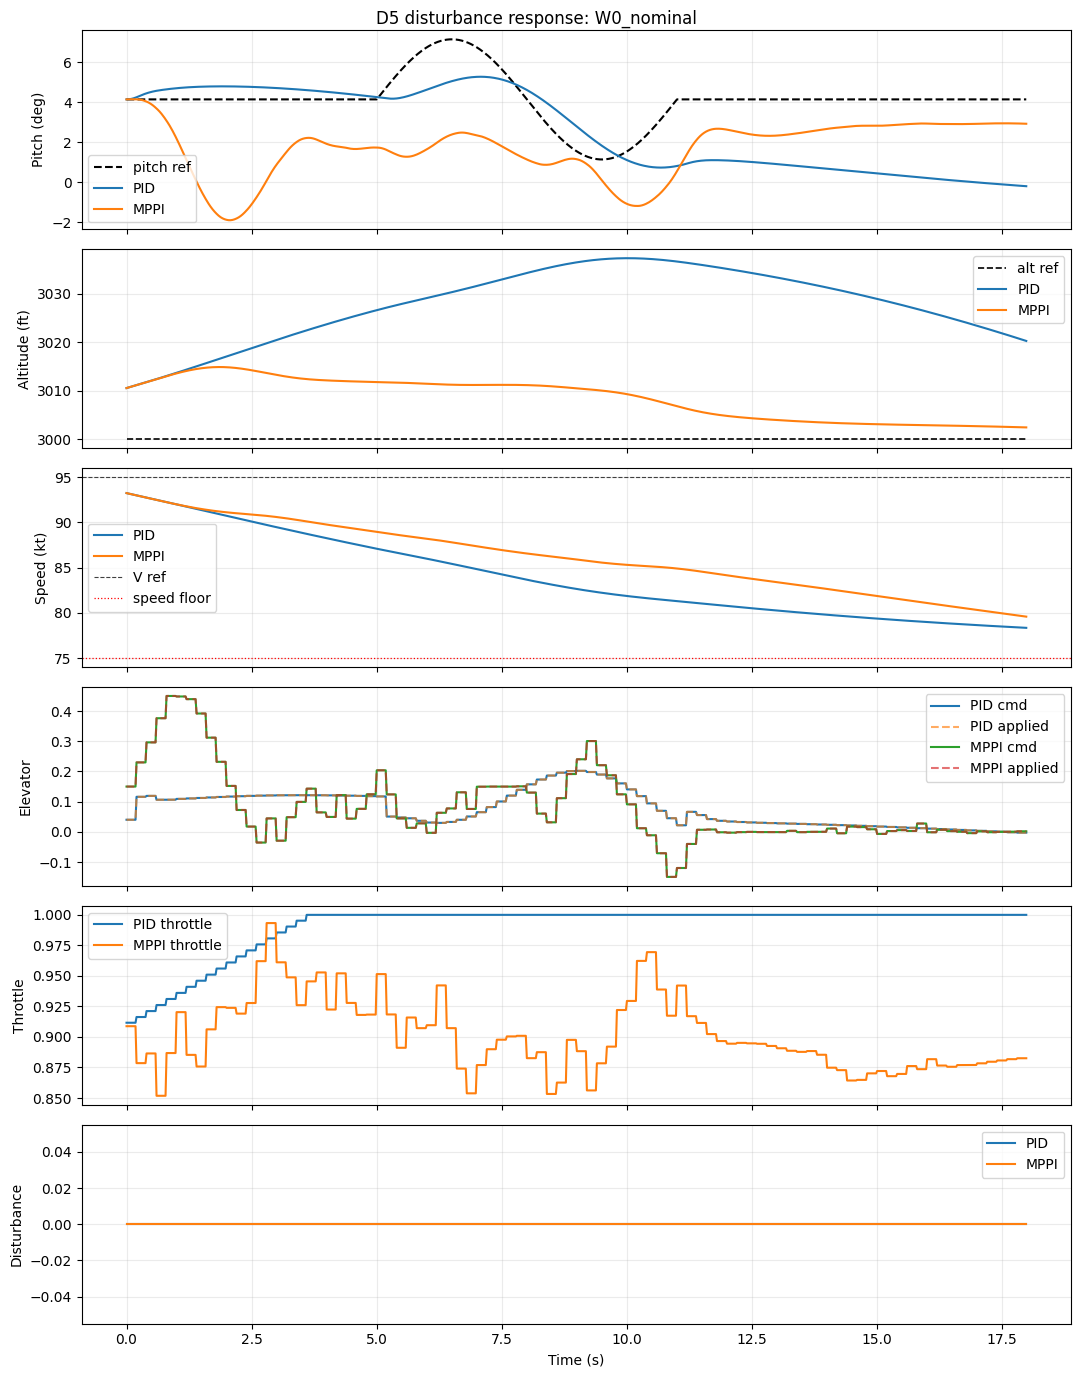

Saved: /content/drive/MyDrive/Colab Result/PINN_MPC/v7_alpha_throttle_snc_D5_2input_MPPI_PID_v38_settle_trim_start/archive/20260503_121835/disturbance_sweep_D5_response_v32_disturbance_sweep_2input_fast_W1_step_up_weak.png


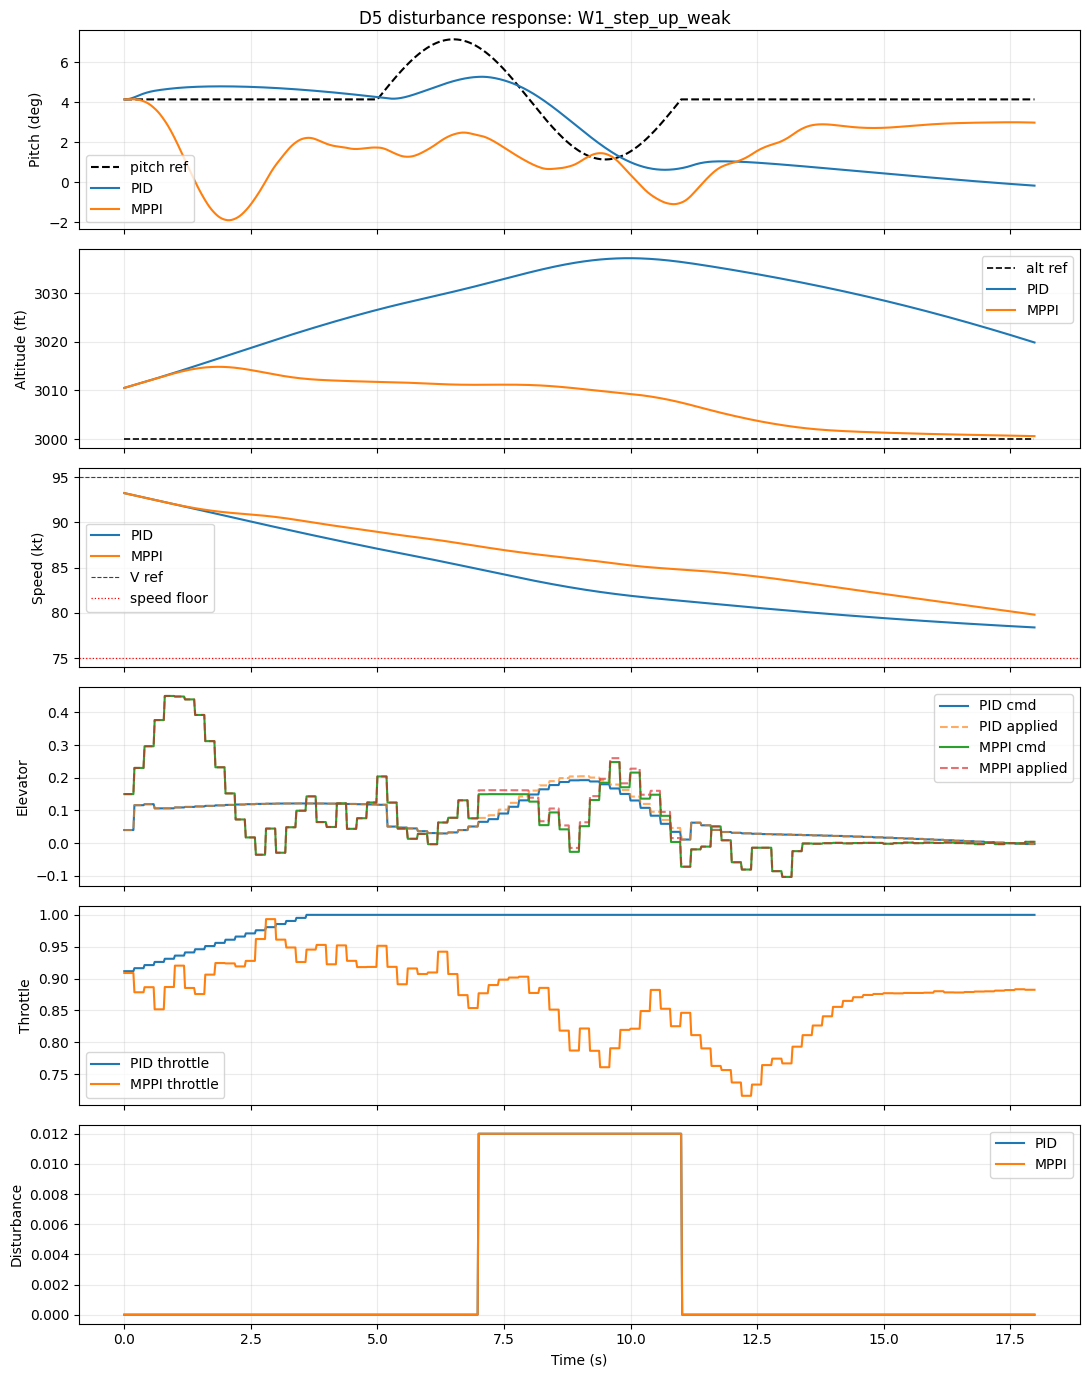

Saved: /content/drive/MyDrive/Colab Result/PINN_MPC/v7_alpha_throttle_snc_D5_2input_MPPI_PID_v38_settle_trim_start/archive/20260503_121835/disturbance_sweep_D5_response_v32_disturbance_sweep_2input_fast_W2_step_down_weak.png


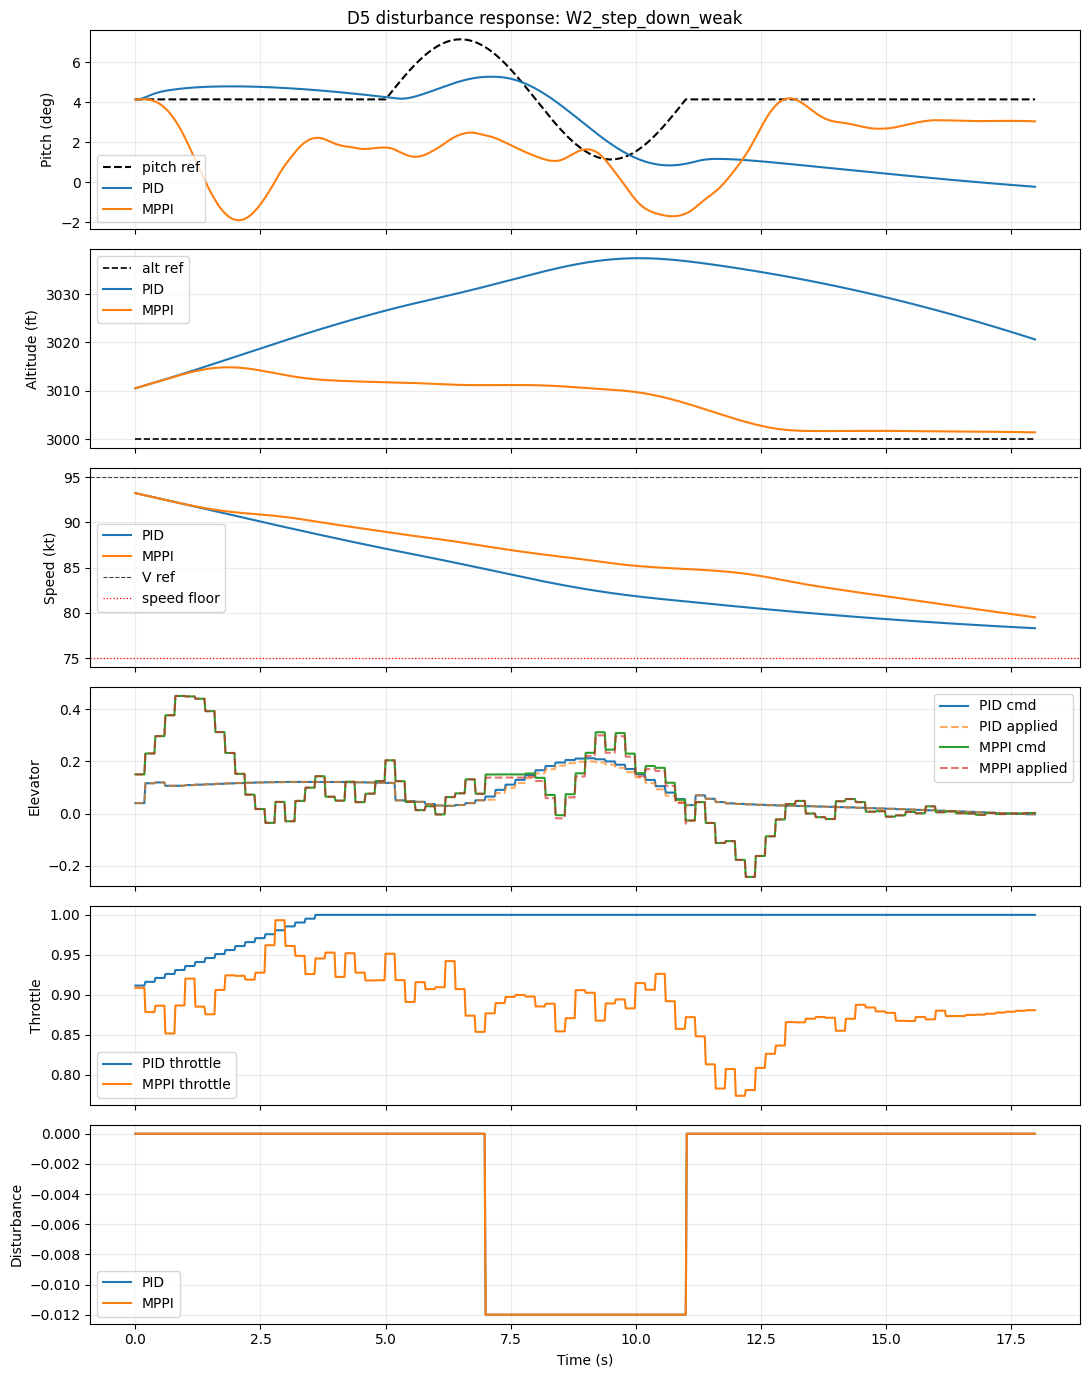

Saved: /content/drive/MyDrive/Colab Result/PINN_MPC/v7_alpha_throttle_snc_D5_2input_MPPI_PID_v38_settle_trim_start/archive/20260503_121835/disturbance_sweep_D5_response_v32_disturbance_sweep_2input_fast_W3_sine_slow.png


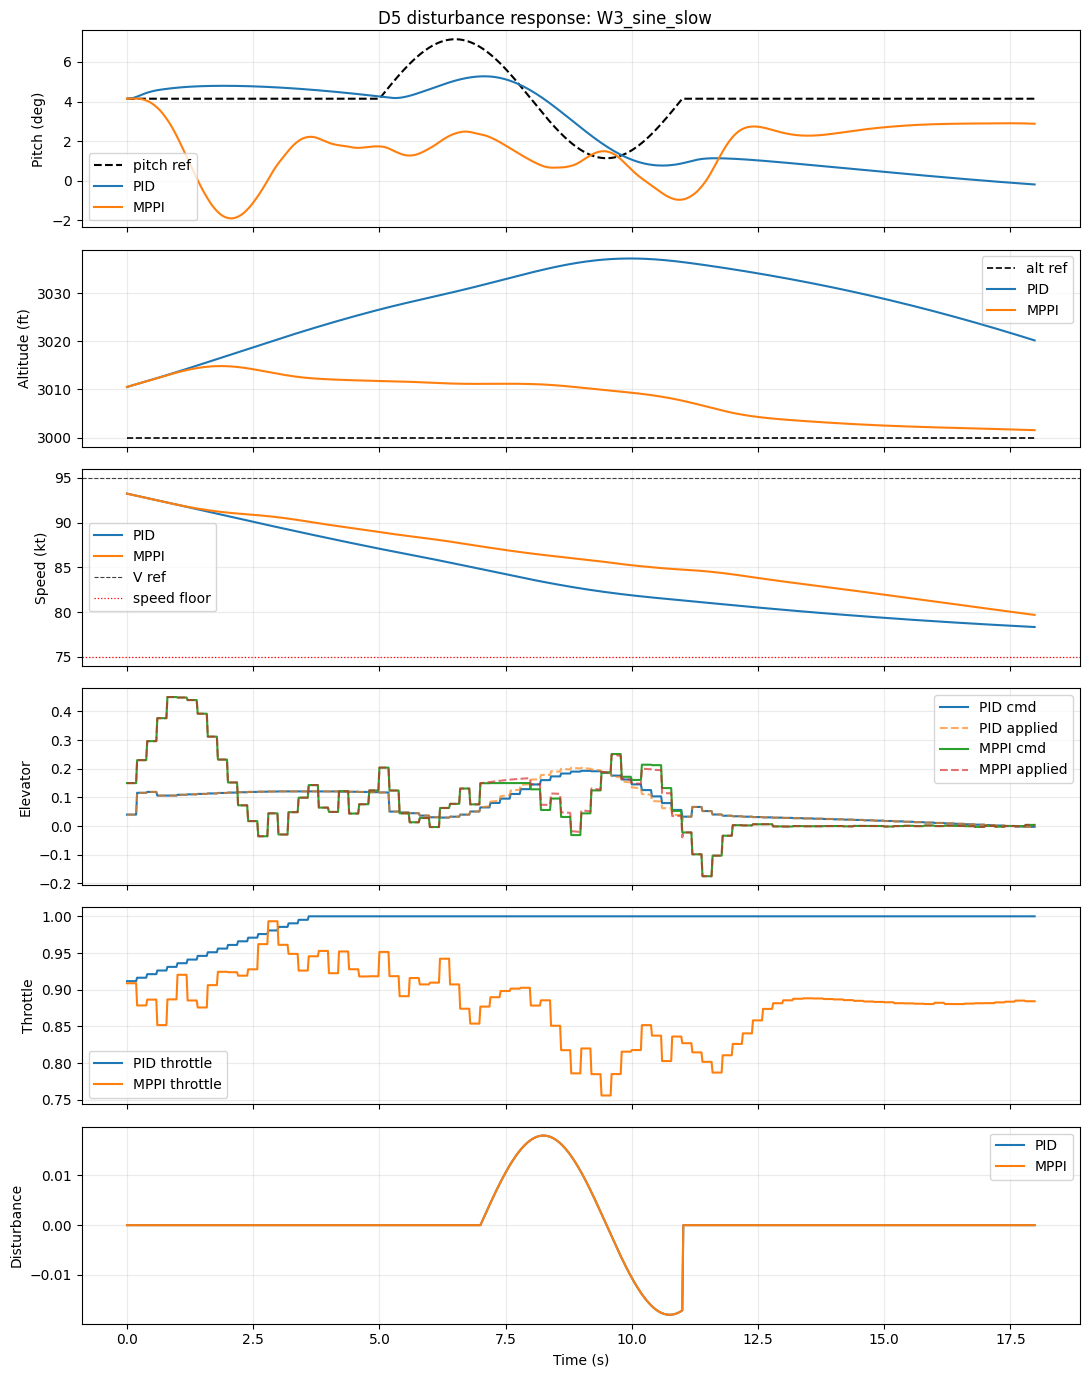

Saved: /content/drive/MyDrive/Colab Result/PINN_MPC/v7_alpha_throttle_snc_D5_2input_MPPI_PID_v38_settle_trim_start/archive/20260503_121835/disturbance_sweep_D5_response_v32_disturbance_sweep_2input_fast_W4_sine_fast.png


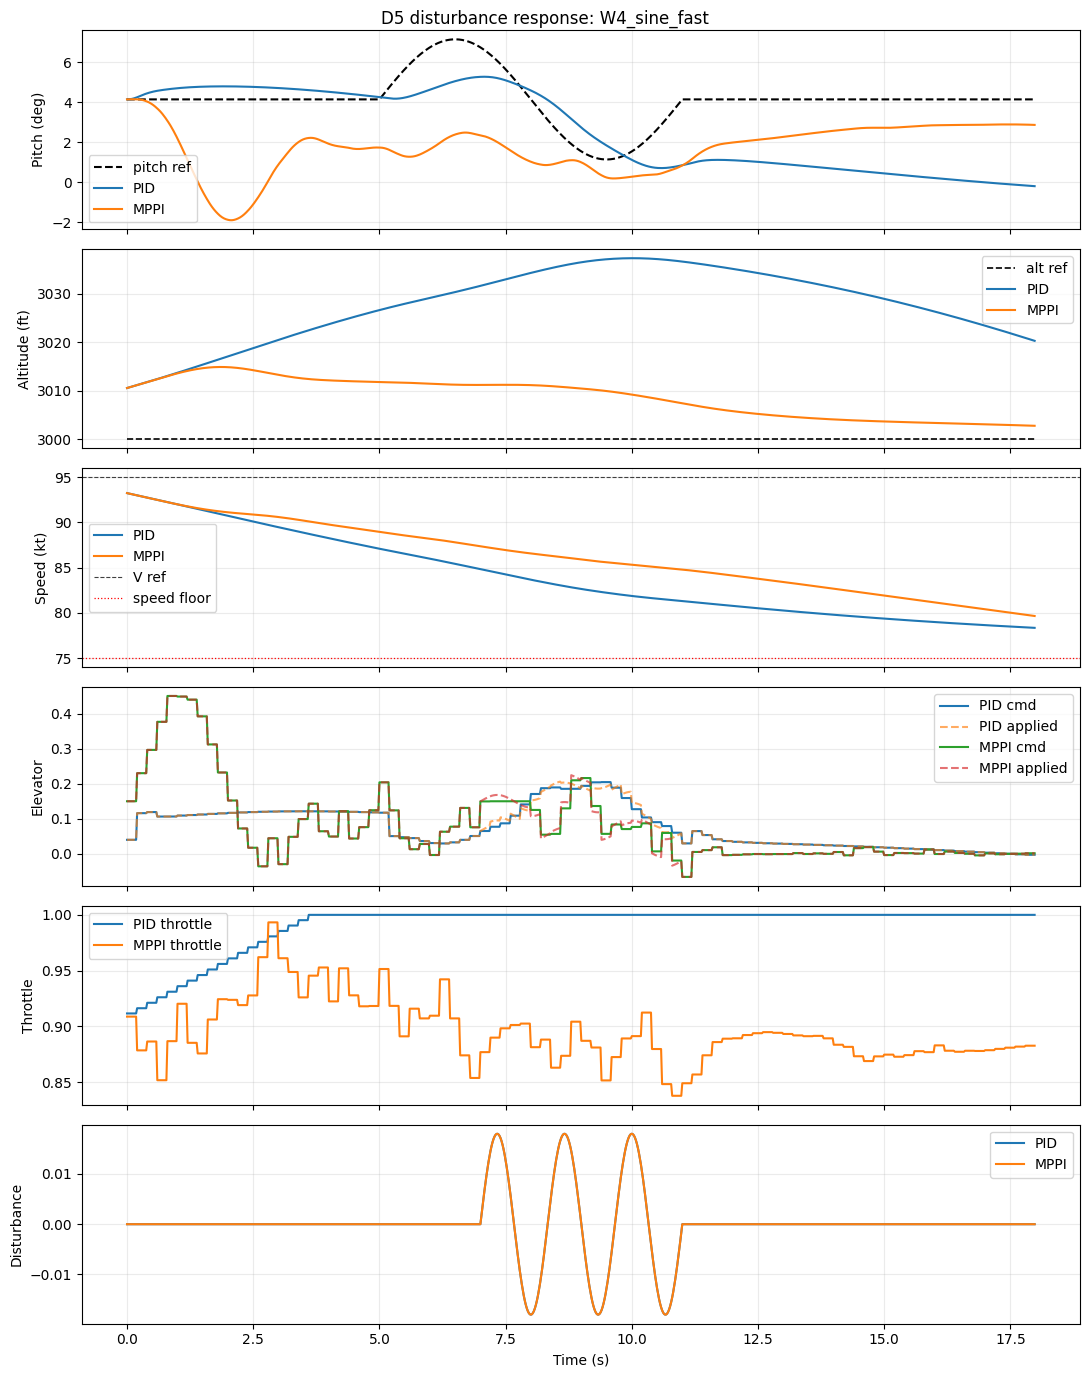

Saved: /content/drive/MyDrive/Colab Result/PINN_MPC/v7_alpha_throttle_snc_D5_2input_MPPI_PID_v38_settle_trim_start/archive/20260503_121835/disturbance_sweep_D5_response_v32_disturbance_sweep_2input_fast_W5_mixed_up_medium.png


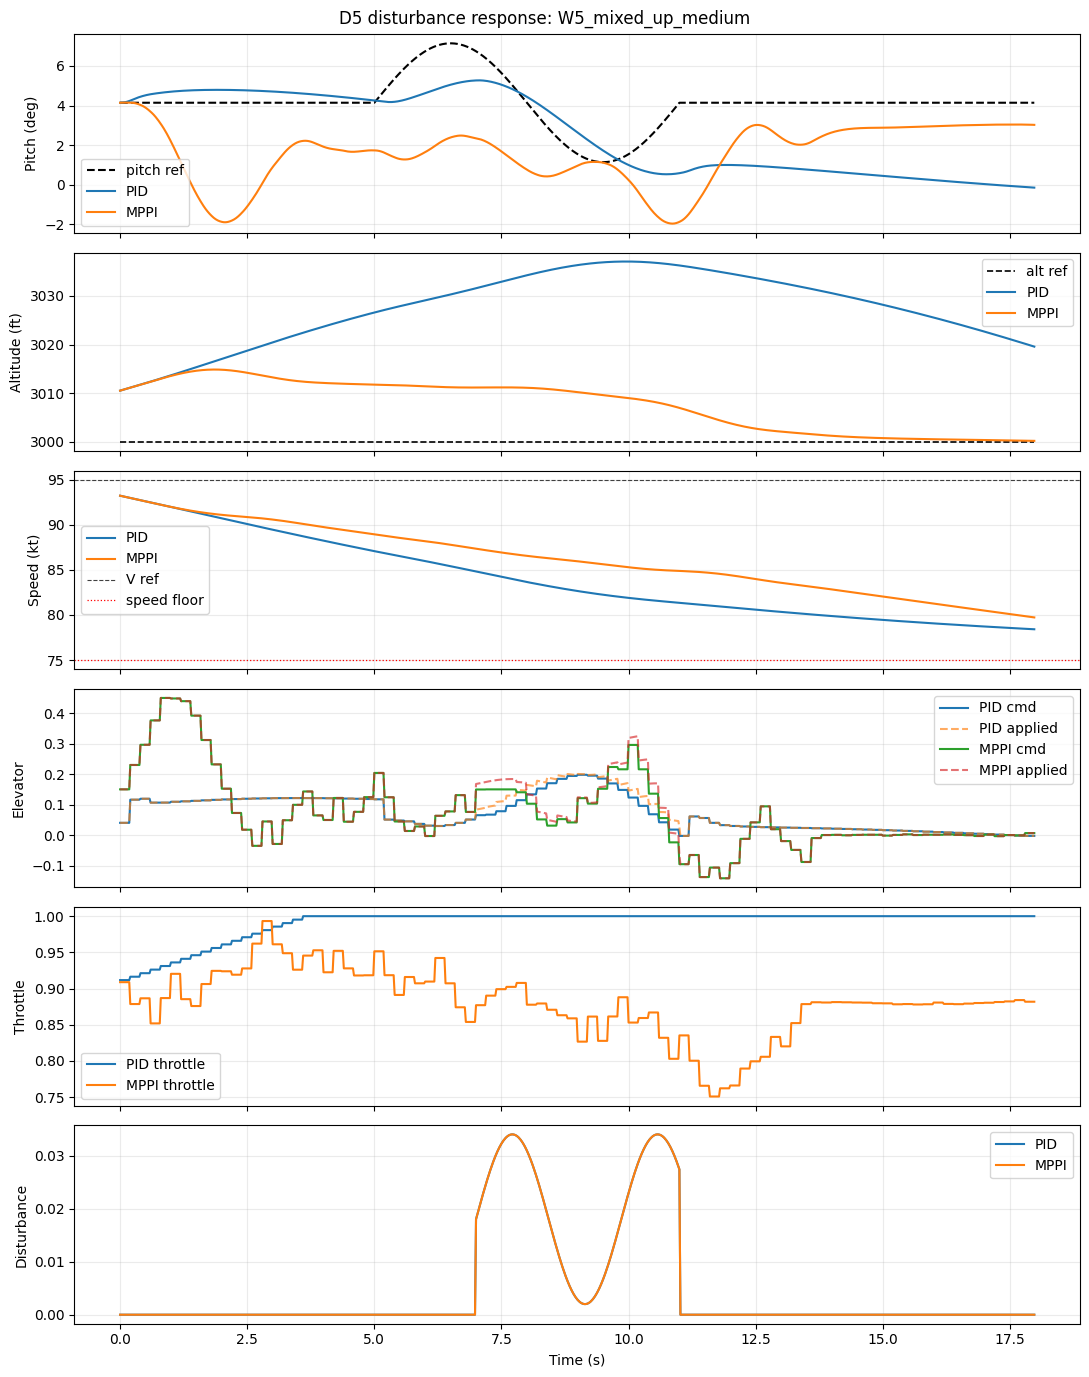

Saved: /content/drive/MyDrive/Colab Result/PINN_MPC/v7_alpha_throttle_snc_D5_2input_MPPI_PID_v38_settle_trim_start/archive/20260503_121835/disturbance_sweep_D5_response_v32_disturbance_sweep_2input_fast_W6_mixed_down_medium.png


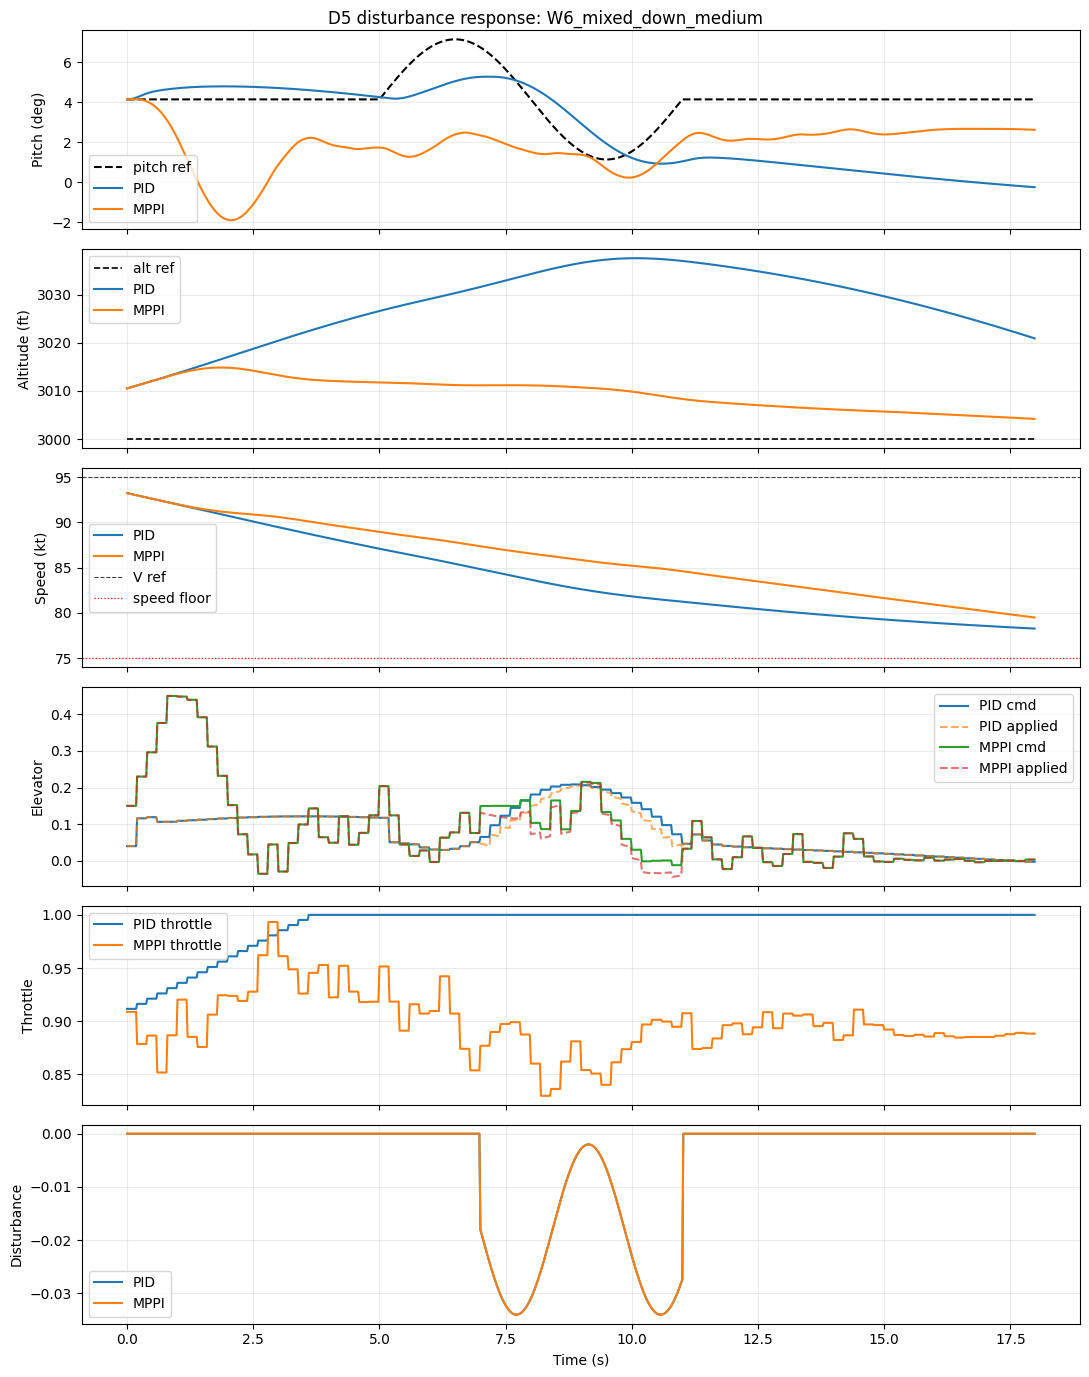

Saved: /content/drive/MyDrive/Colab Result/PINN_MPC/v7_alpha_throttle_snc_D5_2input_MPPI_PID_v38_settle_trim_start/archive/20260503_121835/disturbance_sweep_D5_response_v32_disturbance_sweep_2input_fast_W7_mixed_up_strong.png


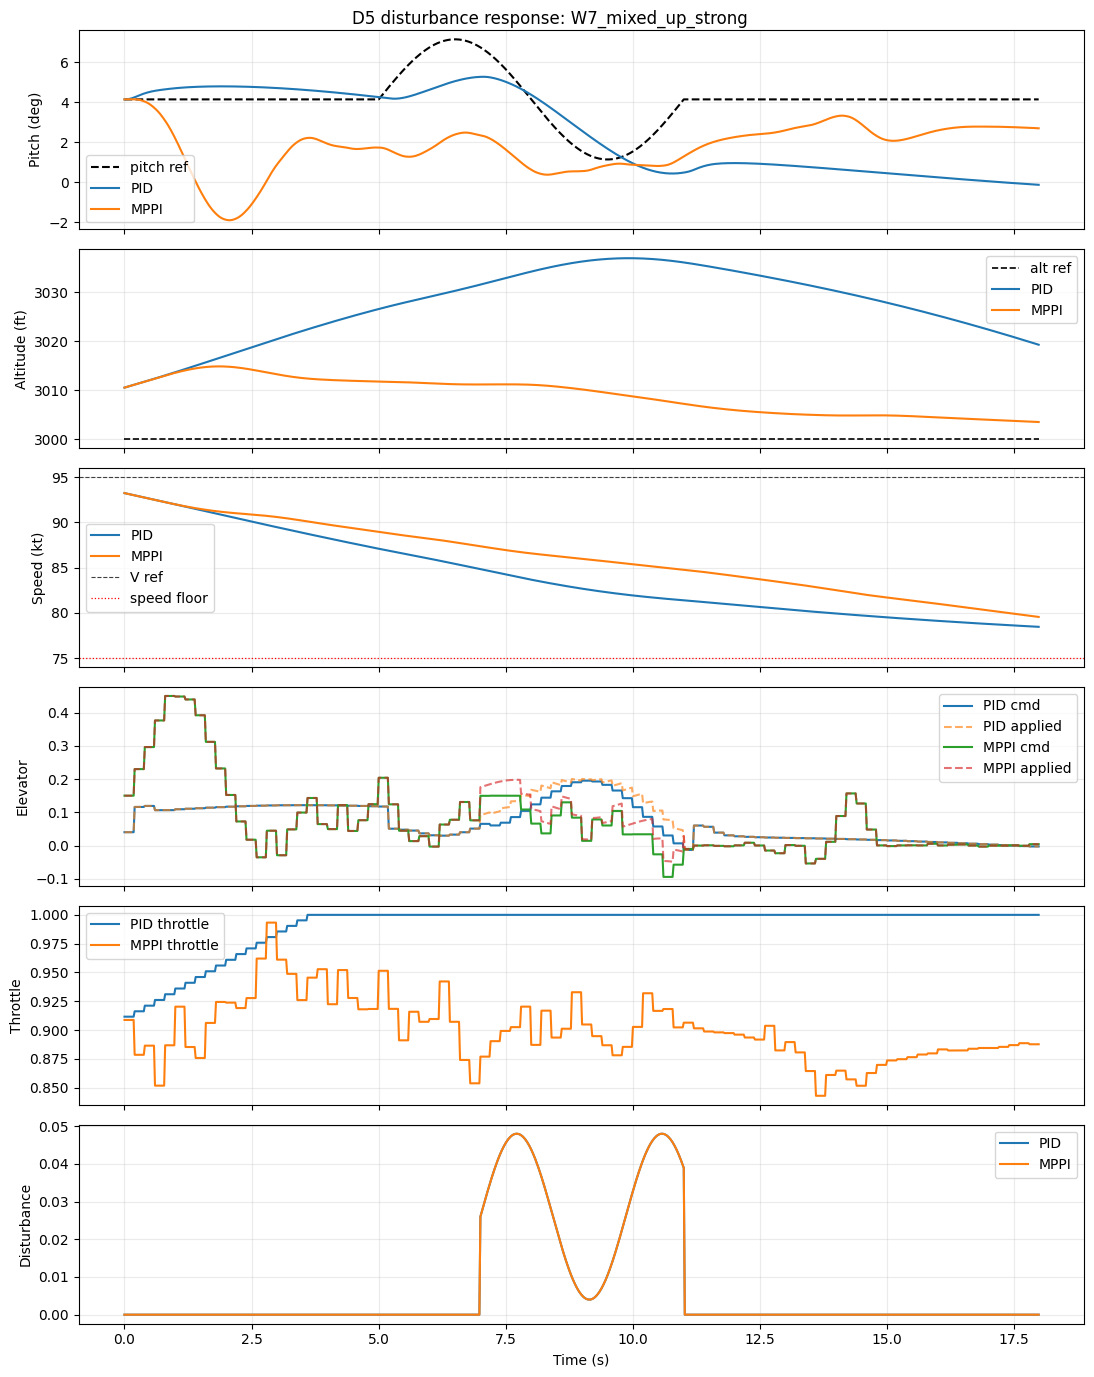

Saved: /content/drive/MyDrive/Colab Result/PINN_MPC/v7_alpha_throttle_snc_D5_2input_MPPI_PID_v38_settle_trim_start/archive/20260503_121835/disturbance_sweep_D5_response_v32_disturbance_sweep_2input_fast_W8_mixed_down_strong.png


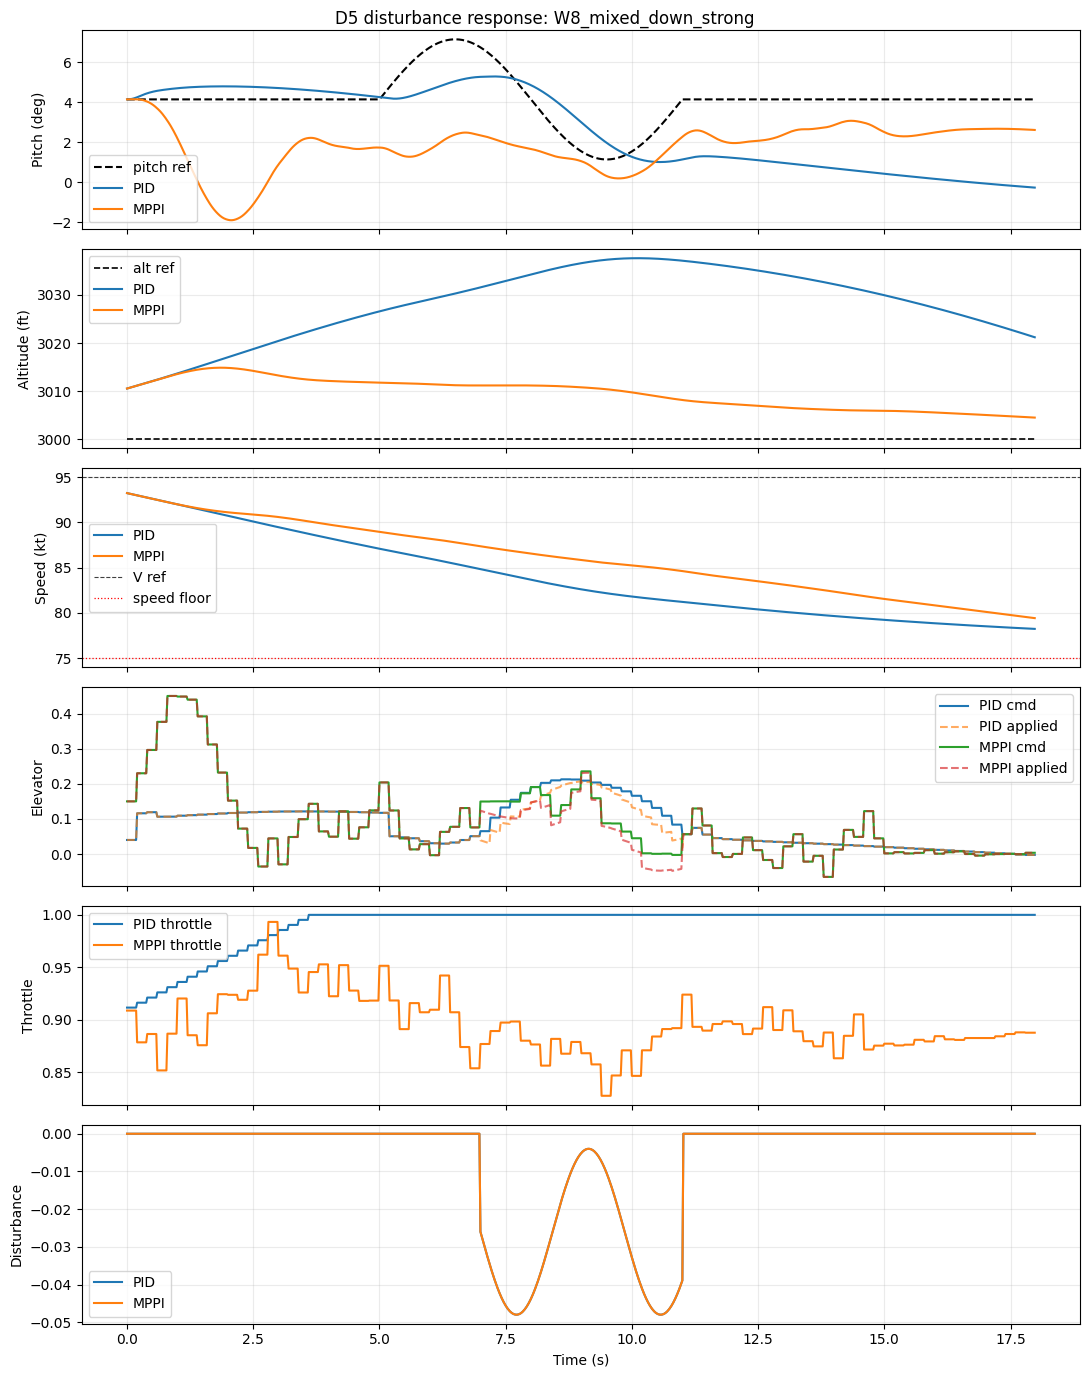

Saved: /content/drive/MyDrive/Colab Result/PINN_MPC/v7_alpha_throttle_snc_D5_2input_MPPI_PID_v38_settle_trim_start/archive/20260503_121835/disturbance_sweep_D5_mppi_minus_pid_delta_v32_disturbance_sweep_2input_fast.png


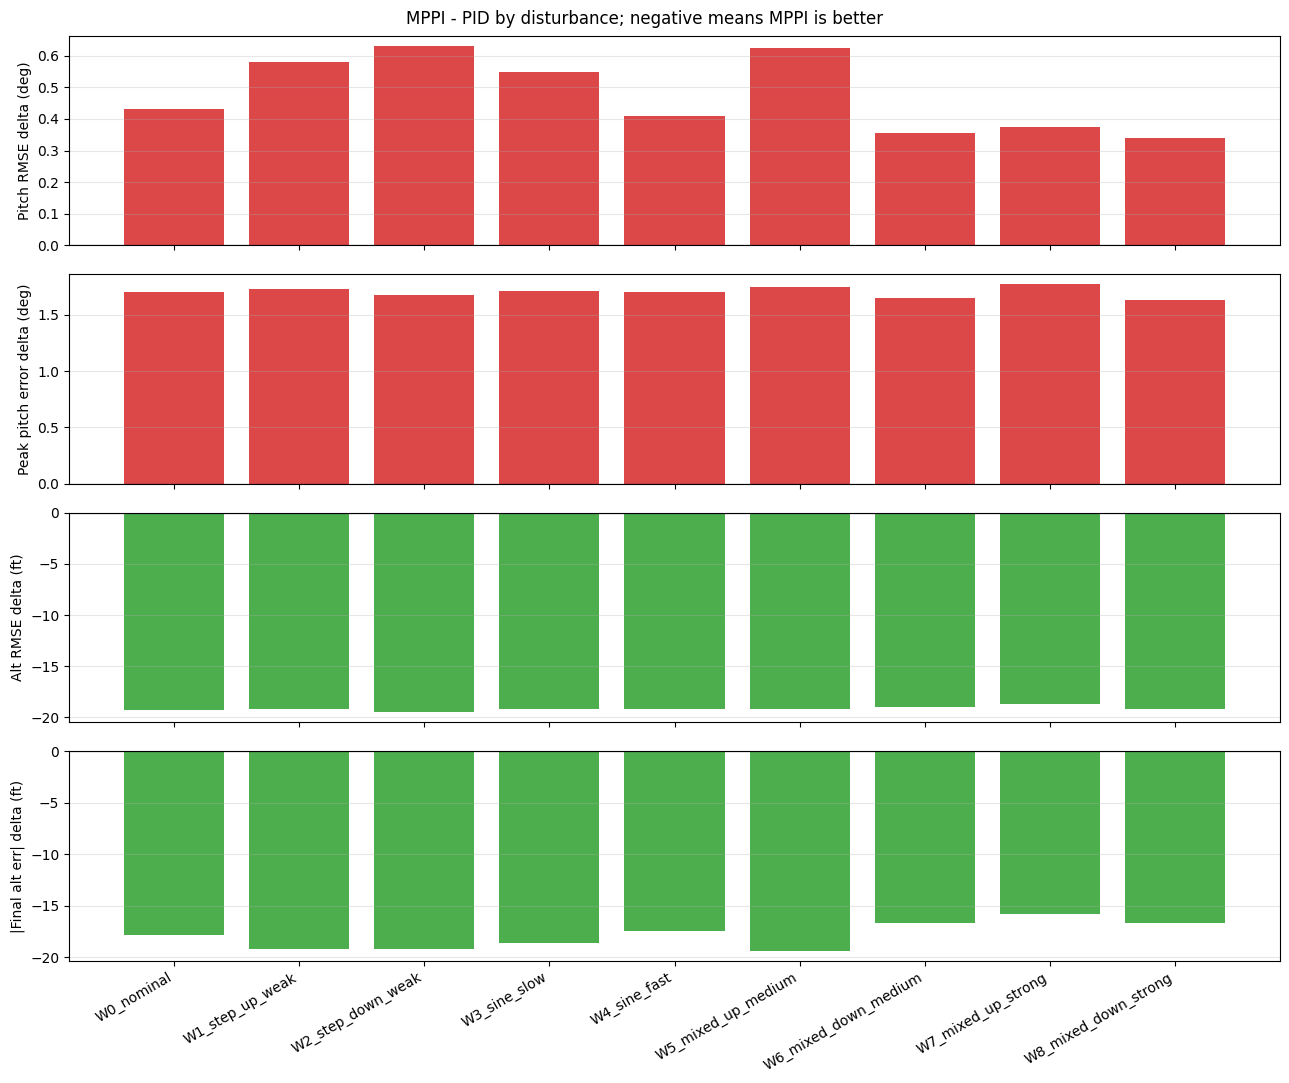

Paper-style disturbance delta table:


,Disturbance,Disturbance Family,Disturbance Severity,MPPI_minus_PID_Pitch_RMSE,MPPI_minus_PID_Peak_Error,MPPI_minus_PID_Alt_RMSE,MPPI_minus_PID_Abs_Final_Error,MPPI_minus_PID_Speed_Loss
0,W0_nominal,none,0.0,0.433,1.700,-19.28,-17.82,-1.23
1,W1_step_up_weak,step,1.0,0.580,1.728,-19.20,-19.24,-1.41
2,W2_step_down_weak,step,1.0,0.631,1.672,-19.51,-19.21,-1.21
3,W3_sine_slow,sine,1.0,0.549,1.711,-19.21,-18.63,-1.35
4,W4_sine_fast,sine,1.0,0.410,1.702,-19.16,-17.50,-1.31
5,W5_mixed_up_medium,mixed,2.0,0.624,1.749,-19.18,-19.38,-1.31
6,W6_mixed_down_medium,mixed,2.0,0.355,1.651,-19.02,-16.71,-1.22
7,W7_mixed_up_strong,mixed,3.0,0.376,1.770,-18.68,-15.79,-1.09
8,W8_mixed_down_strong,mixed,3.0,0.339,1.630,-19.15,-16.72,-1.19


In [80]:
def maneuver_reference_for_log(log):
    return maneuver_reference_arrays(np.asarray(log['time'], dtype=float), log['target_alt'])


def plot_disturbance_case(logs_for_case, title):
    fig, axes = plt.subplots(6, 1, figsize=(11, 14), sharex=True)
    ref_plotted = False
    for log in logs_for_case:
        t = np.asarray(log['time'])
        h_ref, theta_ref_deg = maneuver_reference_for_log(log)
        label = f"{log['name']}"
        if not ref_plotted:
            axes[0].plot(t, theta_ref_deg, 'k--', lw=1.5, label='pitch ref')
            axes[1].plot(t, h_ref, 'k--', lw=1.2, label='alt ref')
            ref_plotted = True
        axes[0].plot(t, log['pitch_deg'], label=label)
        axes[1].plot(t, log['altitude'], label=label)
        axes[2].plot(t, np.asarray(log['velocity']) / FPS_PER_KT, label=label)
        axes[3].plot(t, log['elevator_cmd'], label=f'{label} cmd')
        axes[3].plot(t, log['elevator'], ls='--', alpha=0.65, label=f'{label} applied')
        axes[4].plot(t, log.get('throttle_cmd', log.get('throttle', [])), label=f'{label} throttle')
        axes[5].plot(t, log['elevator_disturbance'], label=label)
    axes[0].set_ylabel('Pitch (deg)')
    axes[1].set_ylabel('Altitude (ft)')
    axes[2].axhline(GUIDANCE_AIRSPEED_KTS, color='0.25', ls='--', lw=0.8, label='V ref')
    axes[2].axhline(SPEED_FLOOR_KTS, color='r', ls=':', lw=0.9, label='speed floor')
    axes[2].set_ylabel('Speed (kt)')
    axes[3].set_ylabel('Elevator')
    axes[4].set_ylabel('Throttle')
    axes[5].set_ylabel('Disturbance')
    axes[5].set_xlabel('Time (s)')
    for ax in axes:
        ax.grid(True, alpha=0.25)
        ax.legend(loc='best')
    fig.suptitle(title)
    plt.tight_layout()
    return fig


def plot_disturbance_delta(disturbance_delta):
    df = disturbance_delta.set_index('Disturbance')
    x = np.arange(len(df))
    fig, axes = plt.subplots(4, 1, figsize=(13, 11), sharex=True)
    metrics_to_plot = [
        ('MPPI_minus_PID_Pitch_RMSE', 'Pitch RMSE delta (deg)'),
        ('MPPI_minus_PID_Peak_Error', 'Peak pitch error delta (deg)'),
        ('MPPI_minus_PID_Alt_RMSE', 'Alt RMSE delta (ft)'),
        ('MPPI_minus_PID_Abs_Final_Error', '|Final alt err| delta (ft)'),
    ]
    for ax, (col, ylabel) in zip(axes, metrics_to_plot):
        colors = ['tab:green' if v < 0 else 'tab:red' for v in df[col].values]
        ax.bar(x, df[col].values, color=colors, alpha=0.85)
        ax.axhline(0.0, color='k', lw=0.8)
        ax.set_ylabel(ylabel)
        ax.grid(True, axis='y', alpha=0.3)
    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(df.index, rotation=30, ha='right')
    fig.suptitle('MPPI - PID by disturbance; negative means MPPI is better')
    plt.tight_layout()
    return fig


plot_paths = []
for disturbance in DISTURBANCE_CASES:
    dname = disturbance['name']
    selected = [log for log in all_logs if log.get('disturbance_case') == dname]
    fig = plot_disturbance_case(selected, title=f'D5 disturbance response: {dname}')
    fig_path = os.path.join(SAVE_DIR, f'disturbance_sweep_D5_response_v32_{RUN_MODE}_{dname}.png')
    fig.savefig(fig_path, dpi=160)
    plot_paths.append(fig_path)
    print('Saved:', fig_path)
    plt.show()

fig = plot_disturbance_delta(disturbance_delta)
delta_plot_path = os.path.join(SAVE_DIR, f'disturbance_sweep_D5_mppi_minus_pid_delta_v32_{RUN_MODE}.png')
fig.savefig(delta_plot_path, dpi=160)
print('Saved:', delta_plot_path)
plt.show()

# Compact table for paper-style reading.
paper_view = disturbance_delta[[
    'Disturbance', 'Disturbance Family', 'Disturbance Severity',
    'MPPI_minus_PID_Pitch_RMSE', 'MPPI_minus_PID_Peak_Error',
    'MPPI_minus_PID_Alt_RMSE', 'MPPI_minus_PID_Abs_Final_Error', 'MPPI_minus_PID_Speed_Loss'
]].copy()
print('Paper-style disturbance delta table:')
display(paper_view)


## 10. Optional Full Comparison


In [81]:
def make_test_cases(n_cases=N_TEST_CASES):
    cases = []
    rng = np.random.default_rng(SEED + 100)
    for i in range(n_cases):
        cases.append({
            'case': i,
            'init_alt': float(rng.uniform(2400, 4200)),
            'init_speed': float(rng.uniform(88, 112)),
            'init_pitch': float(rng.uniform(-4, 6)),
            'target_alt': float(rng.uniform(4400, 5600)),
        })
    return cases


all_logs = []
all_metrics = []

if RUN_MODE == 'full':
    cases = make_test_cases()
    for case in cases:
        print('Case:', case)
        for name in SELECTED_CONTROLLERS:
            ctrl = make_controller(name)
            log = run_sim(
                ctrl, name,
                init_alt=case['init_alt'],
                init_speed=case['init_speed'],
                init_pitch=case['init_pitch'],
                target_alt=case['target_alt'],
                max_steps=MAX_STEPS,
                control_interval=CONTROL_INTERVAL,
            )
            m = compute_metrics(log)
            m['Case'] = case['case']
            all_logs.append(log)
            all_metrics.append(m)

multi_metrics = pd.DataFrame(all_metrics)
if len(multi_metrics):
    multi_metrics.to_csv(os.path.join(SAVE_DIR, 'multi_case_metrics_v7_alpha_throttle_full.csv'), index=False)
multi_metrics


""


## 11. Save Logs


In [82]:
def logs_to_frame(logs):
    rows = []
    for idx, log in enumerate(logs):
        n = len(log['time'])
        h_ref, theta_ref_deg = maneuver_reference_for_log(log)
        for k in range(n):
            rows.append({
                'log_id': idx,
                'disturbance_case': log.get('disturbance_case', 'unknown'),
                'disturbance_kind': log.get('disturbance_kind', 'unknown'),
                'controller': log['name'],
                'time': log['time'][k],
                'altitude': log['altitude'][k],
                'guidance_altitude': float(h_ref[k]),
                'guidance_error_ft': float(log['altitude'][k] - h_ref[k]),
                'theta_ref_deg': float(theta_ref_deg[k]),
                'theta_error_deg': float(log['pitch_deg'][k] - theta_ref_deg[k]),
                'velocity': log['velocity'][k],
                'velocity_kt': float(log['velocity'][k] / FPS_PER_KT),
                'speed_ref_kt': float(GUIDANCE_AIRSPEED_KTS),
                'speed_floor_kt': float(SPEED_FLOOR_KTS),
                'pitch_deg': log['pitch_deg'][k],
                'pitch_rate_deg_s': log['pitch_rate_deg_s'][k],
                'alpha_deg': log['alpha_deg'][k],
                'elevator': log['elevator'][k],
                'elevator_cmd': log['elevator_cmd'][k],
                'elevator_disturbance': log['elevator_disturbance'][k],
                'theta_cmd_deg': log['theta_cmd_deg'][k],
                'cost': log['cost'][k],
                'comp_ms': log['comp_ms'][k],
                'mpc_update': log['mpc_update'][k],
                'target_alt': log['target_alt'],
                'init_alt': log['init_alt'],
                'control_interval': log['control_interval'],
                'abort_reason': log['abort_reason'] or 'None',
            })
    return pd.DataFrame(rows)


single_log_df = logs_to_frame(logs)
multi_log_df = logs_to_frame(all_logs)
single_log_df.to_csv(os.path.join(SAVE_DIR, f'snc_smooth_pitch_doublet_alt_hold_augmented_tracking_logs_v31_fix3_fix1_{RUN_MODE}_baseline.csv'), index=False)
multi_log_df.to_csv(os.path.join(SAVE_DIR, f'snc_smooth_pitch_doublet_alt_hold_augmented_tracking_logs_v31_fix3_fix1_{RUN_MODE}_all_cases.csv'), index=False)
sanity_df.to_csv(os.path.join(SAVE_DIR, f'cost_sanity_snc_smooth_pitch_doublet_alt_hold_augmented_v31_fix3_fix1_{RUN_MODE}.csv'), index=False)
speed_unit_df.to_csv(os.path.join(SAVE_DIR, f'speed_unit_sanity_v31_fix3_fix1_{RUN_MODE}.csv'), index=False)

config_path = os.path.join(SAVE_DIR, f'pinn_mpc_v7_alpha_throttle_snc_D5_2input_config_v38_settle_trim_start_{RUN_MODE}.json')
with open(config_path, 'w') as f:
    json.dump({
        'config': CONFIG,
        'pid_params': PID_PARAMS,
        'pid_optuna_best_value': None if pid_study is None else float(pid_study.best_value),
        'model_path': MODEL_PATH,
        'pinn_params': params,
        'pinn_auto_summary': checkpoint.get('auto_summary', {}),
    }, f, indent=2)

run_manifest = {
    'experiment_family': EXPERIMENT_FAMILY,
    'experiment_name': EXPERIMENT_NAME,
    'run_stamp': RUN_STAMP,
    'save_dir': SAVE_DIR,
    'latest_dir': RESULT_LATEST_DIR,
    'run_mode': RUN_MODE,
    'model_path': MODEL_PATH,
    'generated_files': sorted([name for name in os.listdir(SAVE_DIR)]),
    'plot_paths': plot_paths,
}
with open(os.path.join(SAVE_DIR, 'RUN_MANIFEST.json'), 'w') as f:
    json.dump(run_manifest, f, indent=2)
with open(os.path.join(RESULT_MODEL_DIR, 'LATEST_RUN.json'), 'w') as f:
    json.dump(run_manifest, f, indent=2)

print('Saved archived results to:', SAVE_DIR)
print('Updated latest run pointer:', os.path.join(RESULT_MODEL_DIR, 'LATEST_RUN.json'))


Saved archived results to: /content/drive/MyDrive/Colab Result/PINN_MPC/v7_alpha_throttle_snc_D5_2input_MPPI_PID_v38_settle_trim_start/archive/20260503_121835
Updated latest run pointer: /content/drive/MyDrive/Colab Result/PINN_MPC/v7_alpha_throttle_snc_D5_2input_MPPI_PID_v38_settle_trim_start/LATEST_RUN.json


## 12. 2-Input v7 Alpha-Throttle Research Notes v38 Settle-Trim Start

- Clean restart from v33 after checkpoint-path confusion.
- Prediction model: `pinn_dynamics_c172_2d_v7_alpha_throttle.pt`.
- Accepted checkpoint roots include `/content/drive/MyDrive`, `/content/drive`, `/content`, and local paths.
- Fixed maneuver: `D5_smooth_doublet`.
- Plant disturbance remains on elevator only; throttle is a controllable energy-management channel.
- MPPI optimizes `[elevator, throttle]` jointly with the nominal v7 PINN.

### v35/v36 cleanup history
- Removed the temporary Colab Drive checkpoint probing cell; checkpoint resolution now lives only in the configuration/load path.
- Renamed stale legacy output filenames to v7 alpha-throttle names.
- Cleared execution outputs so the notebook starts from a clean state.

### v38 settle-trim-start
- Fixed the 2-input plant interface: `apply_control()` now accepts commanded throttle and returns the applied throttle.
- Fixed PID Optuna rollout calls that passed throttle positionally while also passing `t=` by keyword.
